# Env Setting

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


def getFMPData(endpoint, urlhead=None, apikey=None, **params):
    if urlhead is None:
        urlhead = "https://financialmodelingprep.com/stable/"
    if apikey is None:
        apikey = os.getenv("FMP_API_KEY")

    if "from_" in params:
        params["from"] = params.pop("from_")

    url = urlhead + endpoint
    param_lst = [f"apikey={apikey}"] + [str(k) + "=" + str(v) for k, v in params.items()]
    url = "?".join([url, "&".join(param_lst)])
    data = requests.get(url).json()
    return data

epsilon = 1e-6

In [4]:
base_url = "https://financialmodelingprep.com/stable/"
endpoint = "income-statement"

endpoint.lstrip("n")

'income-statement'

# Get SP500 Symbols

In [2]:
sp500_info = pd.read_csv("sp500List.csv")
sp500_info

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


# Get Stock Universe

In [4]:
rules = {
    'marketCapMoreThan': 500000000,
    'exchange': 'NYSE',
    'country': 'US',
    'isEtf': 'false',
    'isFund': 'false',
    'isActivelyTrading': 'true',
    'limit': 5000,
    'priceMoreThan': 5,
    'volumeMoreThan': 200000,
}

In [5]:
tickers_df = pd.DataFrame()
for exchange in ['NYSE', 'NASDAQ', 'AMEX']:
    rules['exchange'] = exchange
    tickers = pd.DataFrame(getFMPData('company-screener', **rules))
    tickers_df = pd.concat([tickers_df, tickers], ignore_index=True)
    print(f"{exchange}: {tickers.shape[0]} tickers")

NYSE: 910 tickers
NASDAQ: 707 tickers
AMEX: 7 tickers


In [6]:
tickers_df

,symbol,companyName,marketCap,sector,industry,beta,price,lastAnnualDividend,volume,exchange,exchangeShortName,country,isEtf,isFund,isActivelyTrading
0,BRK-B,Berkshire Hathaway Inc.,1108460175091,Financial Services,Insurance - Diversified,0.709000,513.81,0.0000,2308672,New York Stock Exchange,NYSE,US,False,False,True
1,LLY,Eli Lilly and Company,963348484992,Healthcare,Drug Manufacturers - General,0.389000,1072.43,6.0000,2679190,New York Stock Exchange,NYSE,US,False,False,True
2,WMT,Walmart Inc.,881079777492,Consumer Defensive,Discount Stores,0.649000,110.51,0.9125,9822215,New York Stock Exchange,NYSE,US,False,False,True
3,JPM,JPMorgan Chase & Co.,852285879319,Financial Services,Banks - Diversified,1.076000,313.08,5.5500,4322448,New York Stock Exchange,NYSE,US,False,False,True
4,V,Visa Inc.,649403317875,Financial Services,Financial - Credit Services,0.820000,334.67,2.6800,4061188,New York Stock Exchange,NYSE,US,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,UEC,Uranium Energy Corp.,5710534688,Energy,Uranium,1.337000,12.27,0.0000,4403931,New York Stock Exchange Arca,AMEX,US,False,False,True
1620,LEU,Centrus Energy Corp.,4535891338,Energy,Uranium,1.307000,259.30,0.0000,434532,New York Stock Exchange Arca,AMEX,US,False,False,True
1621,UUUU,Energy Fuels Inc.,3416929459,Energy,Uranium,2.049000,14.40,0.0000,5080371,New York Stock Exchange Arca,AMEX,US,False,False,True
1622,ETH,Grayscale Ethereum Mini Trust,2289514017,Financial Services,Asset Management - Cryptocurrency,4.440146,28.59,0.0000,3814787,New York Stock Exchange Arca,AMEX,US,False,False,True


In [100]:
tickers_df.to_csv("universe/stockUniverse_20251123.csv", index=False)

In [7]:
tickers_df = pd.read_csv("universe/stockUniverse_20251123.csv")
tickers_df.shape

(1996, 15)

In [9]:
tickers_df.head()

,symbol,companyName,marketCap,sector,industry,beta,price,lastAnnualDividend,volume,exchange,exchangeShortName,country,isEtf,isFund,isActivelyTrading
0,BRK-B,Berkshire Hathaway Inc.,1087383010918,Financial Services,Insurance - Diversified,0.709,504.04,0.0000,6032898,New York Stock Exchange,NYSE,US,False,False,True
1,LLY,Eli Lilly and Company,951913308604,Healthcare,Drug Manufacturers - General,0.389,1059.70,6.0000,4140633,New York Stock Exchange,NYSE,US,False,False,True
2,WMT,Walmart Inc.,839700680169,Consumer Defensive,Discount Stores,0.649,105.32,0.9125,41298838,New York Stock Exchange,NYSE,US,False,False,True
3,JPM,JPMorgan Chase & Co.,811288609156,Financial Services,Banks - Diversified,1.076,298.02,5.5500,11742526,New York Stock Exchange,NYSE,US,False,False,True
4,V,Visa Inc.,636421848975,Financial Services,Financial - Credit Services,0.820,327.98,2.6800,8832314,New York Stock Exchange,NYSE,US,False,False,True


# Get Stock Price History

In [10]:
tickers_df.shape

(1996, 15)

In [11]:
sampled_ticker_df = tickers_df.sample(100)
sampled_ticker_df.head()

,symbol,companyName,marketCap,sector,industry,beta,price,lastAnnualDividend,volume,exchange,exchangeShortName,country,isEtf,isFund,isActivelyTrading
851,HNI,HNI Corporation,1875319718,Industrials,Business Equipment & Supplies,0.920,40.91,1.35,986251,New York Stock Exchange,NYSE,US,False,False,True
1593,HTFL,"Heartflow, Inc. Common Stock",2627146481,Healthcare,Medical - Healthcare Information Services,NaN,30.85,NaN,819234,NASDAQ Global Select,NASDAQ,US,False,False,True
723,BXMT,"Blackstone Mortgage Trust, Inc.",3247641203,Real Estate,REIT - Mortgage,1.111,18.85,1.88,1344455,New York Stock Exchange,NYSE,US,False,False,True
1075,NVDA,NVIDIA Corporation,4355191360000,Technology,Semiconductors,2.269,178.88,0.04,346926153,NASDAQ Global Select,NASDAQ,US,False,False,True
1762,HCSG,"Healthcare Services Group, Inc.",1314530910,Healthcare,Medical - Care Facilities,0.765,17.97,0.00,662794,NASDAQ Global Select,NASDAQ,US,False,False,True


In [21]:
# sampled_ticker_df['symbol'].tolist()

In [12]:
tk_price_df = pd.DataFrame()
for tk in sampled_ticker_df['symbol'].tolist():

    kwargs = {
        'symbol': tk,
        'from': '2015-01-01',
        'to': '2025-10-30'
    }

    price_df = pd.DataFrame(getFMPData('historical-price-eod/dividend-adjusted', **kwargs))
    tk_price_df = pd.concat([tk_price_df, price_df], ignore_index=True)

In [17]:
tk_price_df = tk_price_df.sort_values(['symbol', 'date']).reset_index(drop=True)
tk_price_df

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume
0,ACLX,2022-02-04,19.00,19.00,15.79,16.80,1093132
1,ACLX,2022-02-07,18.05,18.05,15.65,17.84,451377
2,ACLX,2022-02-08,16.98,18.14,16.75,17.78,132255
3,ACLX,2022-02-09,18.07,18.49,16.37,16.40,137844
4,ACLX,2022-02-10,16.99,17.34,16.19,16.86,111587
...,...,...,...,...,...,...,...
237434,XMTR,2025-10-24,51.28,51.83,49.72,49.77,761333
237435,XMTR,2025-10-27,50.45,51.43,50.11,50.43,403600
237436,XMTR,2025-10-28,50.45,50.90,49.36,49.39,300152
237437,XMTR,2025-10-29,49.61,51.83,49.26,50.52,335438


In [19]:
(tk_price_df.groupby('symbol').size()<2724).mean()

0.23

In [21]:
tk_price_df['r1'] = np.log(1 + tk_price_df.groupby('symbol')['adjClose'].pct_change(1))
tk_price_df

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume,r1
0,ACLX,2022-02-04,19.00,19.00,15.79,16.80,1093132,NaN
1,ACLX,2022-02-07,18.05,18.05,15.65,17.84,451377,0.060064
2,ACLX,2022-02-08,16.98,18.14,16.75,17.78,132255,-0.003369
3,ACLX,2022-02-09,18.07,18.49,16.37,16.40,137844,-0.080793
4,ACLX,2022-02-10,16.99,17.34,16.19,16.86,111587,0.027663
...,...,...,...,...,...,...,...,...
237434,XMTR,2025-10-24,51.28,51.83,49.72,49.77,761333,-0.009598
237435,XMTR,2025-10-27,50.45,51.43,50.11,50.43,403600,0.013174
237436,XMTR,2025-10-28,50.45,50.90,49.36,49.39,300152,-0.020838
237437,XMTR,2025-10-29,49.61,51.83,49.26,50.52,335438,0.022621


In [23]:
_tk = tk_price_df['symbol'].drop_duplicates().sample(1)
_tk

145051    NFLX
Name: symbol, dtype: object

In [24]:
tk_price_df[tk_price_df['symbol']==_tk.item()]

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume,r1
145051,NFLX,2015-01-02,4.92,5.03,4.87,4.98,134748250,NaN
145052,NFLX,2015-01-05,4.93,4.93,4.71,4.73,181650210,-0.051505
145053,NFLX,2015-01-06,4.73,4.76,4.57,4.65,160379520,-0.017058
145054,NFLX,2015-01-07,4.73,4.74,4.63,4.67,98500220,0.004292
145055,NFLX,2015-01-08,4.71,4.78,4.65,4.78,96242090,0.023281
...,...,...,...,...,...,...,...,...
147770,NFLX,2025-10-24,111.10,111.45,109.44,109.47,60280250,-0.017118
147771,NFLX,2025-10-27,110.07,110.23,108.73,109.46,46911140,-0.000091
147772,NFLX,2025-10-28,109.40,111.70,109.30,110.25,40209010,0.007191
147773,NFLX,2025-10-29,109.98,110.86,109.60,110.04,33995000,-0.001907


# Build Stock Universe

## Get Entire Stock List

In [21]:
symbolList1 = pd.DataFrame(getFMPData('stock-list'))
symbolList1.shape

(47698, 2)

In [22]:
symbolList1.head(10)

,symbol,companyName
0,SNES,"SenesTech, Inc."
1,OSTX,OS Therapies Incorporated
2,BIEAX,Brandes International Equity Fund
3,CALZF,PolyNovo Limited
4,BBRRF,Blueberries Medical Corp.
5,ADCV,ADCapital US Inc.
6,BVILF,Breville Group Limited
7,BGLC,BioNexus Gene Lab Corp.
8,0I50.L,Trip.com Group Limited
9,HUM.L,Hummingbird Resources PLC


In [23]:
symbolList2 = pd.DataFrame(getFMPData('financial-statement-symbol-list'))
symbolList2.shape

(31969, 4)

In [24]:
symbolList2.head(10)

,symbol,companyName,tradingCurrency,reportingCurrency
0,SNES,"SenesTech, Inc.",USD,USD
1,OSTX,OS Therapies Incorporated,USD,USD
2,CALZF,PolyNovo Limited,USD,AUD
3,BBRRF,Blueberries Medical Corp.,USD,CAD
4,BVILF,Breville Group Limited,USD,AUD
5,BGLC,BioNexus Gene Lab Corp.,USD,USD
6,0I50.L,Trip.com Group Limited,USD,CNY
7,HUM.L,Hummingbird Resources PLC,GBp,USD
8,NCPL,Netcapital Inc.,USD,USD
9,CVCO,"Cavco Industries, Inc.",USD,USD


In [26]:
symbolList3 = symbolList2.loc[symbolList2['tradingCurrency'].isin(['USD'])]
symbolList3.shape

(26270, 4)

In [27]:
symbolList2.groupby(['reportingCurrency']).size().sort_values(ascending=False)

reportingCurrency
USD    19326
CAD     4608
GBP     2214
EUR     1608
JPY      870
AUD      672
CNY      641
HKD      312
CHF      270
SEK      245
SGD      103
ZAR      100
BRL       94
NOK       89
THB       83
MXN       79
DKK       62
PHP       56
IDR       56
ILS       55
MYR       52
NZD       48
RUB       48
PLN       34
INR       34
TWD       29
TRY       25
KRW       20
ARS       17
COP       10
EGP        9
PEN        7
CLP        7
GEL        6
KZT        6
RON        6
CZK        5
NGN        5
HUF        5
SAR        4
GHS        3
VND        3
PGK        2
BDT        1
AED        1
NAD        1
LBP        1
KES        1
ZMW        1
dtype: int64

In [28]:
# companySamples = symbolList3.sample(10)
# companySamples

In [39]:
from time import time, sleep
from tqdm import tqdm

profiles = []
invalidTypes = []
longerRecords = []

MAX_CALLS_PER_WINDOW = 700   # below 750 for safety
WINDOW_SECONDS = 70          # a bit more than 60s

symbols = symbolList3['symbol'].tolist()

call_count = 0
window_start = time()

for symbol in tqdm(symbols, total=len(symbols), desc="Downloading profiles"):
    # --- rate limit with buffer ---
    now = time()
    elapsed = now - window_start

    # If we've used up our call budget in this window, wait
    if call_count >= MAX_CALLS_PER_WINDOW:
        if elapsed < WINDOW_SECONDS:
            wait = WINDOW_SECONDS - elapsed
            print(f"\nRate limit buffer: sleeping {wait:.1f} seconds...")
            sleep(wait)

        # reset window
        window_start = time()
        call_count = 0

    # --- actual API call ---
    profile = getFMPData('profile', symbol=symbol)
    call_count += 1

    # --- handle response ---
    if not isinstance(profile, list):
        print(f"{symbol} - invalid record")
        invalidTypes.append(symbol)
    elif len(profile) != 1:
        print(f"{symbol} - {len(profile)} records")
        longerRecords.append(symbol)
    else:
        profiles += profile



Rate limit buffer: sleeping 40.6 seconds...



Rate limit buffer: sleeping 42.8 seconds...


CLDR - 0 records



Rate limit buffer: sleeping 49.4 seconds...



Rate limit buffer: sleeping 45.4 seconds...


...

ARFXF - 0 records


SCON - 0 records


VLNCD - 0 records


NNA - 0 records


SNR - 0 records


In [41]:
len(profiles), len(invalidTypes), len(longerRecords)

(26209, 0, 61)

In [42]:
longerRecords

['CLDR',
 'ACICU',
 'CELG',
 'OTH',
 'BML',
 'IPOBU',
 'IPOCU',
 'DVAXW',
 'LDL',
 'RPAI',
 'SMSA',
 'OPLF',
 'BPR',
 'WARR-UN',
 'SCVXW',
 'SGLAD',
 'IMPTV',
 'RHDM',
 'RSTAY',
 'ARFXD',
 'MICTW',
 'TREB-UN',
 'JRVSD',
 'XEC',
 'KDC',
 'CLIRW',
 'TMGID',
 'NXU-UN',
 'TRNEU',
 'ICR',
 'TMSRW',
 'PHEC',
 'TYDEV',
 'LDOC',
 'HTF',
 'CPSR-UN',
 'WHLRW',
 'AZIC',
 'SUNFU',
 'LYLTV',
 'WLFCP',
 'DTIID',
 'EVTVD',
 'HUAK',
 'GRA',
 'PSA-PE',
 'HCG',
 'WCGC',
 'SPAQU',
 'XRXH',
 'TGRF',
 'USB-PM',
 'FOREU',
 'JAX',
 'FLXE',
 'CNSC',
 'ARFXF',
 'SCON',
 'VLNCD',
 'NNA',
 'SNR']

In [43]:
getFMPData('profile', symbol='IPOCU')

[]

In [44]:
profiles_df = pd.DataFrame(profiles)
profiles_df.head()

,symbol,price,marketCap,beta,lastDividend,range,change,changePercentage,volume,averageVolume,companyName,currency,cik,isin,cusip,exchangeFullName,exchange,industry,website,description,ceo,sector,country,fullTimeEmployees,phone,address,city,state,zip,image,ipoDate,defaultImage,isEtf,isActivelyTrading,isAdr,isFund
0,SNES,2.9700,1.551303e+07,0.215000,0.00000,1.3-6.24,0.0500,1.71233,28205,94289.0,"SenesTech, Inc.",USD,0001680378,US81720R6045,81720R208,NASDAQ Capital Market,NASDAQ,Chemicals - Specialty,https://www.senestech.com,"SenesTech, Inc. develops a technology for mana...",Joel L. Fruendt,Basic Materials,US,23,928 779 4143,23460 North 19th Avenue,Phoenix,AZ,85027,https://images.financialmodelingprep.com/symbo...,2016-12-08,False,False,True,False,False
1,OSTX,1.9200,6.761156e+07,-4.041328,0.00000,1.12-7,0.1000,5.49451,509594,333435.0,OS Therapies Incorporated,USD,0001795091,US68764Y2072,None,New York Stock Exchange,NYSE,Biotechnology,https://ostherapies.com,"OS Therapies Incorporated, a clinical stage bi...",Paul A. Romness,Healthcare,US,4,410-297-7793,15825 Shady Grove Road Suite 135,Rockville,MD,20850,https://images.financialmodelingprep.com/symbo...,2024-08-01,True,False,True,False,False
2,CALZF,0.7990,5.519836e+08,1.686000,0.00000,0.615-1.82,0.0500,6.67557,10175,1196.0,PolyNovo Limited,USD,None,AU000000PNV0,None,Other OTC,OTC,Medical - Devices,https://polynovo.com,PolyNovo Limited develops medical devices in t...,Jan-Marcel Gielen,Healthcare,AU,282,61 3 8681 4050,320 Lorimer Street,Port Melbourne,VIC,3207,https://images.financialmodelingprep.com/symbo...,2021-01-08,False,False,True,False,False
3,BBRRF,0.0105,5.198446e+06,3.188000,0.00000,0.0038-0.0208,0.0024,29.62963,60000,17631.0,Blueberries Medical Corp.,USD,None,CA09609Y1016,None,Other OTC,OTC,Drug Manufacturers - Specialty & Generic,https://blueberriesmed.com,Blueberries Medical Corp. engages in the growt...,Facundo Garreton,Healthcare,CO,None,57 3 161 70133,Calle 93 # 15 - 51 Oficina 406,Bogotá,None,None,https://images.financialmodelingprep.com/symbo...,2019-02-08,False,False,True,False,False
4,BVILF,18.7500,2.697449e+09,1.169000,0.23971,18.75-25.11,0.0000,0.00000,2000,65.0,Breville Group Limited,USD,None,AU000000BRG2,None,Other OTC,OTC,"Furnishings, Fixtures & Appliances",https://brevillegroup.com,"Breville Group Limited designs, develops, mark...",Jim Clayton,Consumer Cyclical,AU,1079,61 2 9384 8100,170-180 Bourke Road,Alexandria,NSW,2015,https://images.financialmodelingprep.com/symbo...,2012-03-14,False,False,True,False,False


In [49]:
path = 'universe/stockUniverseProfile.csv'
profiles_df.to_csv(path, index=False)

In [2]:
path = 'universe/stockUniverseProfile.csv'
profiles_df = pd.read_csv(path)

In [26]:
cols = [
    'symbol',
    'price',
    'marketCap',
    'beta',
    'changePercentage',
    'volume',
    'currency',
    'exchange',
    'industry',
    'sector',
    'country',
    'ipoDate',
    # 'isEtf',
    # 'isFund',
    'isActivelyTrading',
]

profiles_df[cols]

,symbol,price,marketCap,beta,changePercentage,volume,currency,exchange,industry,sector,country,ipoDate,isActivelyTrading
0,SNES,2.9700,1.551303e+07,0.215000,1.71233,28205,USD,NASDAQ,Chemicals - Specialty,Basic Materials,US,2016-12-08,True
1,OSTX,1.9200,6.761156e+07,-4.041328,5.49451,509594,USD,NYSE,Biotechnology,Healthcare,US,2024-08-01,True
2,CALZF,0.7990,5.519836e+08,1.686000,6.67557,10175,USD,OTC,Medical - Devices,Healthcare,AU,2021-01-08,True
3,BBRRF,0.0105,5.198446e+06,3.188000,29.62963,60000,USD,OTC,Drug Manufacturers - Specialty & Generic,Healthcare,CO,2019-02-08,True
4,BVILF,18.7500,2.697449e+09,1.169000,0.00000,2000,USD,OTC,"Furnishings, Fixtures & Appliances",Consumer Cyclical,AU,2012-03-14,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26204,DRTT,0.3343,3.491596e+07,1.227467,-0.35770,152917,USD,NASDAQ,Engineering & Construction,Industrials,CA,2014-01-28,False
26205,HIL,3.4000,0.000000e+00,0.000000,0.00000,128887,USD,NYSE,Engineering & Construction,Industrials,US,2004-06-25,False
26206,ATRRF,112.6900,2.625210e+09,0.815000,0.00000,48,USD,OTC,REIT - Residential,Real Estate,FR,2018-06-25,True
26207,IEA,13.7200,0.000000e+00,1.733870,-0.43540,5101286,USD,NASDAQ,Engineering & Construction,Industrials,US,2016-07-07,False


In [4]:
profiles_df['exchange'].value_counts(dropna=False)

exchange
OTC       12644
NASDAQ     7974
NYSE       4311
LSE         820
AMEX        416
PNK          24
CBOE         10
TSX           9
TSXV          1
Name: count, dtype: int64

In [13]:
profiles_df.dtypes

symbol                object
price                float64
marketCap            float64
beta                 float64
lastDividend         float64
range                 object
change               float64
changePercentage     float64
volume                 int64
averageVolume        float64
companyName           object
currency              object
cik                  float64
isin                  object
cusip                 object
exchangeFullName      object
exchange              object
industry              object
website               object
description           object
ceo                   object
sector                object
country               object
fullTimeEmployees    float64
phone                 object
address               object
city                  object
state                 object
zip                   object
image                 object
ipoDate               object
defaultImage            bool
isEtf                   bool
isActivelyTrading       bool
isAdr         

In [27]:
usTradingProfiles = profiles_df.loc[profiles_df['exchange'].isin(['NASDAQ', 'NYSE', 'AMEX']) & (~profiles_df['isEtf']) & (~profiles_df['isFund']), cols]
usTradingProfiles

,symbol,price,marketCap,beta,changePercentage,volume,currency,exchange,industry,sector,country,ipoDate,isActivelyTrading
0,SNES,2.9700,1.551303e+07,0.215000,1.71233,28205,USD,NASDAQ,Chemicals - Specialty,Basic Materials,US,2016-12-08,True
1,OSTX,1.9200,6.761156e+07,-4.041328,5.49451,509594,USD,NYSE,Biotechnology,Healthcare,US,2024-08-01,True
5,BGLC,4.1100,7.383656e+06,2.214000,-5.08083,21371,USD,NASDAQ,Medical - Diagnostics & Research,Healthcare,MY,2021-01-08,True
7,NCPL,0.8413,4.136232e+06,0.816000,-7.55961,219306,USD,NASDAQ,Financial - Capital Markets,Financial Services,US,2006-06-05,True
8,CVCO,578.6400,4.626267e+09,1.287000,0.11246,181356,USD,NASDAQ,Residential Construction,Consumer Cyclical,US,2003-07-01,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26203,BRMK,4.8200,6.350350e+08,1.164300,-2.62630,4464111,USD,NYSE,REIT - Mortgage,Real Estate,US,2019-11-15,False
26204,DRTT,0.3343,3.491596e+07,1.227467,-0.35770,152917,USD,NASDAQ,Engineering & Construction,Industrials,CA,2014-01-28,False
26205,HIL,3.4000,0.000000e+00,0.000000,0.00000,128887,USD,NYSE,Engineering & Construction,Industrials,US,2004-06-25,False
26207,IEA,13.7200,0.000000e+00,1.733870,-0.43540,5101286,USD,NASDAQ,Engineering & Construction,Industrials,US,2016-07-07,False


In [28]:
usTradingProfiles['isActivelyTrading'].value_counts(dropna=False)

isActivelyTrading
True     6601
False    5018
Name: count, dtype: int64

In [29]:
usTradingProfiles[usTradingProfiles['symbol'].isin(['OCFT'])]

,symbol,price,marketCap,beta,changePercentage,volume,currency,exchange,industry,sector,country,ipoDate,isActivelyTrading
10286,OCFT,7.89,8.603634e+09,1.887,0.0,122441,USD,NYSE,Software - Application,Technology,CN,2019-12-13,True


## Get Delisted Stock List

In [19]:
delisted = pd.DataFrame(getFMPData('delisted-companies', page=36, limit=10000))
# delisted = pd.DataFrame(getFMPData('delisted-companies', page=0, limit=10000))
delisted.shape

(0, 0)

In [23]:
# getFMPData('delisted-companies', page=35, limit=10000)

In [24]:
delisted_all = []
for i in range(1000):
    delisted = getFMPData('delisted-companies', page=i, limit=10000)
    if len(delisted)==0:
        break
    else:
        delisted_all += delisted

delisted_all_df = pd.DataFrame(delisted_all)
delisted_all_df.shape

(3569, 5)

In [25]:
delisted_all_df

,symbol,companyName,exchange,ipoDate,delistedDate
0,HSS.L,HSS Hire Group plc,LSE,2015-02-04,2025-11-28
1,OCFT,"OneConnect Financial Technology Co., Ltd.",NYSE,2019-12-13,2025-11-20
2,DRREF,Dream Residential Real Estate Investment Trust,OTC,2022-08-31,2025-11-20
3,QLGN,"Qualigen Therapeutics, Inc.",NASDAQ,2015-06-23,2025-11-19
4,IMNG,iMing Corp.,OTC,2023-06-12,2025-11-18
...,...,...,...,...,...
3564,PRL,Progress Rail Services Inc.,NYSE,1993-10-27,2006-06-21
3565,TSA,The Sports Authority Inc,NYSE,1994-08-03,2006-05-10
3566,ACOR,"Acorda Therapeutics, Inc.",NASDAQ,2006-02-10,2006-04-15
3567,6967.T,"Shinko Electric Industries Co., Ltd.",JPX,2005-09-29,2005-06-06


In [41]:
delisted_all_df2 = delisted_all_df[delisted_all_df['exchange'].isin(['NASDAQ', 'NYSE', 'AMEX'])].drop_duplicates(subset=['symbol'])
delisted_all_df2

,symbol,companyName,exchange,ipoDate,delistedDate
1,OCFT,"OneConnect Financial Technology Co., Ltd.",NYSE,2019-12-13,2025-11-20
3,QLGN,"Qualigen Therapeutics, Inc.",NASDAQ,2015-06-23,2025-11-19
5,SRDX,"Surmodics, Inc.",NASDAQ,1998-03-04,2025-11-18
6,FSST,Fidelity Sustainable U.S. Equity ETF,AMEX,2021-06-17,2025-11-17
7,LCG,Sterling Capital Focus Equity ETF,AMEX,2020-08-27,2025-11-17
...,...,...,...,...,...
3562,FSTW,"Firstwave Tech, Inc.",NASDAQ,1993-02-04,2007-09-21
3564,PRL,Progress Rail Services Inc.,NYSE,1993-10-27,2006-06-21
3565,TSA,The Sports Authority Inc,NYSE,1994-08-03,2006-05-10
3566,ACOR,"Acorda Therapeutics, Inc.",NASDAQ,2006-02-10,2006-04-15


In [42]:
delisted_all_df2['symbol'].duplicated().sum()

0

In [43]:
# delisted_all_df2[delisted_all_df2['symbol'].isin(delisted_all_df2.loc[delisted_all_df2['symbol'].duplicated(), 'symbol'])]

In [48]:
usTradingProfiles['delistedDate'] = usTradingProfiles['symbol'].map(delisted_all_df2[['symbol', 'delistedDate']].set_index('symbol')['delistedDate'])
usTradingProfiles

,symbol,price,marketCap,beta,changePercentage,volume,currency,exchange,industry,sector,country,ipoDate,isActivelyTrading,delistedDate
0,SNES,2.9700,1.551303e+07,0.215000,1.71233,28205,USD,NASDAQ,Chemicals - Specialty,Basic Materials,US,2016-12-08,True,NaN
1,OSTX,1.9200,6.761156e+07,-4.041328,5.49451,509594,USD,NYSE,Biotechnology,Healthcare,US,2024-08-01,True,NaN
5,BGLC,4.1100,7.383656e+06,2.214000,-5.08083,21371,USD,NASDAQ,Medical - Diagnostics & Research,Healthcare,MY,2021-01-08,True,NaN
7,NCPL,0.8413,4.136232e+06,0.816000,-7.55961,219306,USD,NASDAQ,Financial - Capital Markets,Financial Services,US,2006-06-05,True,NaN
8,CVCO,578.6400,4.626267e+09,1.287000,0.11246,181356,USD,NASDAQ,Residential Construction,Consumer Cyclical,US,2003-07-01,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26203,BRMK,4.8200,6.350350e+08,1.164300,-2.62630,4464111,USD,NYSE,REIT - Mortgage,Real Estate,US,2019-11-15,False,2023-05-30
26204,DRTT,0.3343,3.491596e+07,1.227467,-0.35770,152917,USD,NASDAQ,Engineering & Construction,Industrials,CA,2014-01-28,False,NaN
26205,HIL,3.4000,0.000000e+00,0.000000,0.00000,128887,USD,NYSE,Engineering & Construction,Industrials,US,2004-06-25,False,2022-12-23
26207,IEA,13.7200,0.000000e+00,1.733870,-0.43540,5101286,USD,NASDAQ,Engineering & Construction,Industrials,US,2016-07-07,False,2022-10-06


In [49]:
usTradingProfiles['delistedDate'].notna().sum()

2485

In [50]:
path = 'universe/stock-universe-usTrading-delistedIncl.csv'
usTradingProfiles.to_csv(path, index=False)

## Final Universe

In [2]:
path = 'universe/stock-universe-usTrading-delistedIncl.csv'
stockUniverse = pd.read_csv(path)

In [3]:
stockUniverse

,symbol,price,marketCap,beta,changePercentage,volume,currency,exchange,industry,sector,country,ipoDate,isActivelyTrading,delistedDate
0,SNES,2.9700,1.551303e+07,0.215000,1.71233,28205,USD,NASDAQ,Chemicals - Specialty,Basic Materials,US,2016-12-08,True,NaN
1,OSTX,1.9200,6.761156e+07,-4.041328,5.49451,509594,USD,NYSE,Biotechnology,Healthcare,US,2024-08-01,True,NaN
2,BGLC,4.1100,7.383656e+06,2.214000,-5.08083,21371,USD,NASDAQ,Medical - Diagnostics & Research,Healthcare,MY,2021-01-08,True,NaN
3,NCPL,0.8413,4.136232e+06,0.816000,-7.55961,219306,USD,NASDAQ,Financial - Capital Markets,Financial Services,US,2006-06-05,True,NaN
4,CVCO,578.6400,4.626267e+09,1.287000,0.11246,181356,USD,NASDAQ,Residential Construction,Consumer Cyclical,US,2003-07-01,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11614,BRMK,4.8200,6.350350e+08,1.164300,-2.62630,4464111,USD,NYSE,REIT - Mortgage,Real Estate,US,2019-11-15,False,2023-05-30
11615,DRTT,0.3343,3.491596e+07,1.227467,-0.35770,152917,USD,NASDAQ,Engineering & Construction,Industrials,CA,2014-01-28,False,NaN
11616,HIL,3.4000,0.000000e+00,0.000000,0.00000,128887,USD,NYSE,Engineering & Construction,Industrials,US,2004-06-25,False,2022-12-23
11617,IEA,13.7200,0.000000e+00,1.733870,-0.43540,5101286,USD,NASDAQ,Engineering & Construction,Industrials,US,2016-07-07,False,2022-10-06


In [9]:
stockUniverse['delistedDate'].isna().sum()

9134

In [10]:
stockUniverse.loc[stockUniverse['delistedDate'].isna(), 'isActivelyTrading'].value_counts()

isActivelyTrading
True     6596
False    2538
Name: count, dtype: int64

In [11]:
cols = [
    'symbol',
    'currency',
    'exchange',
    'industry',
    'sector',
    'isActivelyTrading',
    'ipoDate',
    'delistedDate'
]

stockUniverse[cols]

,symbol,currency,exchange,industry,sector,isActivelyTrading,ipoDate,delistedDate
0,SNES,USD,NASDAQ,Chemicals - Specialty,Basic Materials,True,2016-12-08,NaN
1,OSTX,USD,NYSE,Biotechnology,Healthcare,True,2024-08-01,NaN
2,BGLC,USD,NASDAQ,Medical - Diagnostics & Research,Healthcare,True,2021-01-08,NaN
3,NCPL,USD,NASDAQ,Financial - Capital Markets,Financial Services,True,2006-06-05,NaN
4,CVCO,USD,NASDAQ,Residential Construction,Consumer Cyclical,True,2003-07-01,NaN
...,...,...,...,...,...,...,...,...
11614,BRMK,USD,NYSE,REIT - Mortgage,Real Estate,False,2019-11-15,2023-05-30
11615,DRTT,USD,NASDAQ,Engineering & Construction,Industrials,False,2014-01-28,NaN
11616,HIL,USD,NYSE,Engineering & Construction,Industrials,False,2004-06-25,2022-12-23
11617,IEA,USD,NASDAQ,Engineering & Construction,Industrials,False,2016-07-07,2022-10-06


In [12]:
path = 'universe/info-stock-universe-usTrading-delistedIncl.csv'
stockUniverse[cols].to_csv(path, index=False)

In [2]:
path = 'universe/info-stock-universe-usTrading-delistedIncl.csv'
stocks_df = pd.read_csv(path)
stocks_df

,symbol,currency,exchange,industry,sector,isActivelyTrading,ipoDate,delistedDate
0,SNES,USD,NASDAQ,Chemicals - Specialty,Basic Materials,True,2016-12-08,NaN
1,OSTX,USD,NYSE,Biotechnology,Healthcare,True,2024-08-01,NaN
2,BGLC,USD,NASDAQ,Medical - Diagnostics & Research,Healthcare,True,2021-01-08,NaN
3,NCPL,USD,NASDAQ,Financial - Capital Markets,Financial Services,True,2006-06-05,NaN
4,CVCO,USD,NASDAQ,Residential Construction,Consumer Cyclical,True,2003-07-01,NaN
...,...,...,...,...,...,...,...,...
11614,BRMK,USD,NYSE,REIT - Mortgage,Real Estate,False,2019-11-15,2023-05-30
11615,DRTT,USD,NASDAQ,Engineering & Construction,Industrials,False,2014-01-28,NaN
11616,HIL,USD,NYSE,Engineering & Construction,Industrials,False,2004-06-25,2022-12-23
11617,IEA,USD,NASDAQ,Engineering & Construction,Industrials,False,2016-07-07,2022-10-06


In [91]:
stocks_df = stocks_df[stocks_df['symbol'].notna()]

In [95]:
stocks_df = stocks_df[stocks_df['industry']!='Shell Companies']
stocks_df.shape

(9164, 8)

In [96]:
path = 'universe/info-stock-universe-usTrading-delistedIncl.csv'
stocks_df.to_csv(path, index=False)

In [2]:
path = 'universe/info-stock-universe-usTrading-delistedIncl.csv'
stocks_df = pd.read_csv(path)
stocks_df

,symbol,currency,exchange,industry,sector,isActivelyTrading,ipoDate,delistedDate
0,SNES,USD,NASDAQ,Chemicals - Specialty,Basic Materials,True,2016-12-08,NaN
1,OSTX,USD,NYSE,Biotechnology,Healthcare,True,2024-08-01,NaN
2,BGLC,USD,NASDAQ,Medical - Diagnostics & Research,Healthcare,True,2021-01-08,NaN
3,NCPL,USD,NASDAQ,Financial - Capital Markets,Financial Services,True,2006-06-05,NaN
4,CVCO,USD,NASDAQ,Residential Construction,Consumer Cyclical,True,2003-07-01,NaN
...,...,...,...,...,...,...,...,...
9159,BRMK,USD,NYSE,REIT - Mortgage,Real Estate,False,2019-11-15,2023-05-30
9160,DRTT,USD,NASDAQ,Engineering & Construction,Industrials,False,2014-01-28,NaN
9161,HIL,USD,NYSE,Engineering & Construction,Industrials,False,2004-06-25,2022-12-23
9162,IEA,USD,NASDAQ,Engineering & Construction,Industrials,False,2016-07-07,2022-10-06


# Build Data Pipeline

In [3]:
symbol = 'CVCO'

## Income Statements

In [30]:
incm_stmt = getFMPData('income-statement', symbol=symbol, limit=120, period='quarter')
len(incm_stmt)

94

In [19]:
incm_stmt_df = pd.DataFrame(incm_stmt)
incm_stmt_df.head()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil
0,2025-09-30,SNES,USD,0001680378,2025-11-10,2025-11-10 17:28:02,2025,Q3,690000,257000,433000,400000,0,0,0,1380000,1780000,2037000,49000,55000,6000,29000,-1263000,-1292000,-55000,-1347000,49000,-1298000,0,-1298000,0,0,-1298000,0.0,-1298000,-0.28,-0.28,4668009.0,4668009.0
1,2025-06-30,SNES,USD,0001680378,2025-08-08,2025-08-07 17:36:07,2025,Q2,625000,216000,409000,427000,1532000,64000,1596000,0,2023000,2239000,-2000,4000,6000,35000,-1575000,-1610000,-4000,-1614000,-2000,-1616000,0,-1616000,0,0,-1616000,0.0,-1616000,-0.87,-0.87,1854531.0,1854531.0
2,2025-03-31,SNES,USD,0001680378,2025-05-08,2025-05-08 17:21:24,2025,Q1,485000,172000,313000,418000,1494000,64000,1558000,0,1976000,2148000,-2000,3000,5000,39000,-1621000,-1660000,-3000,-1663000,-2000,-1665000,0,-1665000,0,0,-1665000,0.0,-1665000,-1.28,-1.28,1299971.0,1299971.0
3,2024-12-31,SNES,USD,0001680378,2025-03-13,2025-03-12 17:38:15,2024,Q4,501000,196000,305000,424000,1074000,64000,1138000,0,1562000,1758000,1000,8000,7000,41000,-1207000,-1248000,-9000,-1257000,2000,-1255000,0,-1255000,0,0,-1255000,0.0,-1255000,-2.07,-2.07,729400.0,729400.0
4,2024-09-30,SNES,USD,0001680378,2024-11-12,2024-11-12 17:23:16,2024,Q3,482000,167000,315000,451000,1331000,80000,1411000,0,1862000,2029000,5000,11000,6000,42000,-1465000,-1507000,-40000,-1547000,34000,-1513000,0,-1513000,0,0,-1513000,0.0,-1513000,-2.07,-2.07,729400.0,729400.0


In [20]:
incm_stmt_df.tail()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil
38,2016-03-31,SNES,USD,0001680378,2016-03-31,2016-03-31 00:00:00,2016,Q1,46000,0,46000,470000,1975000,0,1975000,0,2445000,2445000,-48000,0,48000,46000,-2394000,-2440000,41000,-2399000,-89000,-2488000,16000,-2488000,0,0,-2488000,1.964509e-10,-2518000,-149.47,-149.47,16645.0,16645.0
39,2015-12-31,SNES,USD,0001680378,2015-12-31,2015-12-30 19:00:00,2015,Q4,102000,0,102000,1462000,4128000,0,4128000,0,5590000,5590000,-351000,0,351000,46000,-6039000,-6849000,1361000,-5488000,-1712000,-7200000,0,-7200000,0,0,-7200000,5.384209e-10,-7217000,-432.56,-432.54,16645.0,16646.0
40,2015-09-30,SNES,USD,0001680378,2015-09-30,2015-09-29 20:00:00,2015,Q3,46000,0,46000,4625000,3261000,0,3261000,-33000,7886000,7886000,-156000,0,156000,47000,-7826000,-7873000,33000,-7840000,-189000,-8029000,0,-8029000,0,0,-8029000,0.000000e+00,-8029000,-482.37,-482.34,16645.0,16646.0
41,2015-06-30,SNES,USD,0001680378,2015-06-30,2015-06-29 20:00:00,2015,Q2,47000,0,47000,649000,897000,-50000,847000,0,1842000,1842000,0,180000,0,47000,-1452000,-1499000,0,-1499000,-476000,-1975000,0,-1975000,0,0,-1975000,0.000000e+00,-1975000,0.00,0.00,0.0,0.0
42,2015-03-31,SNES,USD,0001680378,2015-03-31,2015-03-30 20:00:00,2015,Q1,46000,0,46000,485000,379000,50000,429000,0,847000,847000,0,168000,0,42000,-776000,-818000,0,-818000,-151000,-969000,0,-969000,0,0,-969000,0.000000e+00,-969000,0.00,0.00,0.0,0.0


## Balance Sheet Statement

In [21]:
bal_stmt = getFMPData('balance-sheet-statement', symbol=symbol, limit=120, period='quarter')
len(bal_stmt)

41

In [22]:
bal_stmt_df = pd.DataFrame(bal_stmt)
bal_stmt_df.head()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,accountsReceivables,otherReceivables,inventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt
0,2025-09-30,SNES,USD,0001680378,2025-11-10,2025-11-10 17:28:02,2025,Q3,7278000,2970000,10248000,454000,454000,0,767000.0,313000,0,11782000,2806000,0,0,0,0,0,36000,2842000,0,14624000,238000,238000,0,333000,60000,95000,0,0,22000,748000,160000,2368000,0,0,0,2528000,0,2463000,3276000,0,0,5000,-140676000,152019000,-2.842171e-08,2.842171e-08,11348000,11348000,0,14624000,2970000,2683000,-4595000
1,2025-06-30,SNES,USD,0001680378,2025-08-08,2025-08-07 17:36:07,2025,Q2,6055000,0,6055000,470000,470000,0,729000.0,39000,181000,7474000,2833000,0,0,0,0,0,58000,2891000,0,10365000,123000,123000,0,310000,59000,52000,0,12000,254000,810000,175000,2403000,0,0,0,2578000,0,2455000,3388000,0,0,4000,-139378000,146351000,0.000000e+00,0.000000e+00,6977000,6977000,0,10365000,0,2689000,-3366000
2,2025-03-31,SNES,USD,0001680378,2025-05-08,2025-05-08 17:21:24,2025,Q1,1655000,0,1655000,498000,498000,0,753000.0,37000,221000,3164000,404000,0,0,0,0,0,58000,462000,0,3626000,164000,164000,0,33000,57000,0,0,12000,277000,543000,191000,0,0,0,0,191000,0,0,734000,0,0,2000,-137762000,140652000,0.000000e+00,0.000000e+00,2892000,2892000,0,3626000,0,248000,-1407000
3,2024-12-31,SNES,USD,0001680378,2025-03-13,2025-03-12 17:38:15,2024,Q4,1307000,0,1307000,335000,335000,0,794000.0,27000,350000,2813000,407000,0,0,0,0,0,58000,465000,0,3278000,215000,215000,0,34000,56000,0,0,12000,244000,561000,206000,0,0,0,0,206000,0,0,767000,0,0,1000,-136097000,138607000,0.000000e+00,0.000000e+00,2511000,2511000,0,3278000,0,262000,-1045000
4,2024-09-30,SNES,USD,0001680378,2024-11-12,2024-11-12 17:23:16,2024,Q3,2518000,0,2518000,214000,214000,0,880000.0,52000,308000,3972000,419000,0,0,0,0,0,58000,477000,0,4449000,128000,128000,0,17000,53000,41000,0,12000,377000,628000,170000,0,0,0,0,170000,0,41000,798000,0,0,1000,-134842000,138492000,0.000000e+00,0.000000e+00,3651000,3651000,0,4449000,0,264000,-2254000


In [23]:
bal_stmt_df.tail()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,accountsReceivables,otherReceivables,inventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt
36,2016-09-30,SNES,USD,0001680378,2016-09-30,2016-09-29 20:00:00,2016,Q3,1345000,0,1345000,17000,17000,0,0.000000e+00,53000,0,1415000,681000,0,0,0,0,0,939000,1620000,0,3035000,621000,621000,0,426000,72000,0,0,46000,46000,1165000,537000,0,0,0,477000,1014000,0,0,2179000,0,8128000,8000,-57621000,58339000,107000.0,0.0,856000,856000,0,3035000,0,609000,-736000
37,2016-06-30,SNES,USD,0001680378,2016-06-30,2016-06-29 20:00:00,2016,Q2,3316000,0,3316000,14000,14000,0,-4.656613e-10,35000,0,3365000,564000,0,0,0,0,0,582000,1146000,0,4511000,393000,393000,0,593000,249000,0,0,128000,428000,1663000,58000,0,0,0,185000,243000,0,0,1906000,0,8128000,7000,-54887000,49261000,77000.0,19000.0,2605000,2605000,0,4511000,0,307000,-3009000
38,2016-03-31,SNES,USD,0001680378,2016-03-31,2016-03-31 00:00:00,2016,Q1,251000,0,251000,0,0,0,0.000000e+00,36000,0,287000,574000,0,0,0,0,0,354000,928000,0,1215000,652000,652000,0,617000,818000,0,0,0,475000,2562000,822000,0,0,0,2235000,3057000,0,0,5619000,0,7903000,22000,-52828000,40479000,20000.0,0.0,-4404000,-4404000,0,1215000,0,1640000,1389000
39,2015-12-31,SNES,USD,0001680378,2015-12-31,2015-12-30 19:00:00,2015,Q4,141000,0,141000,13000,13000,0,0.000000e+00,36000,0,190000,613000,0,0,0,0,0,138000,751000,0,941000,544000,544000,0,425000,689000,0,0,221000,333000,2212000,484000,0,0,0,2091000,2575000,0,0,4787000,0,7476000,4000,-50357000,39000000,17000.0,14000.0,-3846000,-3846000,0,941000,0,1173000,1032000
40,2015-03-31,SNES,USD,0001680378,2015-03-31,2015-03-30 20:00:00,2015,Q1,-821000,1642000,821000,0,0,0,0.000000e+00,0,0,821000,0,0,0,0,0,0,-821000,-821000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-5724000.0,0.0,-5724000,-5724000,0,-5724000,1642000,0,821000


## Cash Flow Statement

In [24]:
cf_stmt = getFMPData('cash-flow-statement', symbol=symbol, limit=120, period='quarter')
len(cf_stmt)

43

In [25]:
cf_stmt_df = pd.DataFrame(cf_stmt)
cf_stmt_df.head()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,netIncome,depreciationAndAmortization,deferredIncomeTax,stockBasedCompensation,changeInWorkingCapital,accountsReceivables,inventory,accountsPayables,otherWorkingCapital,otherNonCashItems,netCashProvidedByOperatingActivities,investmentsInPropertyPlantAndEquipment,acquisitionsNet,purchasesOfInvestments,salesMaturitiesOfInvestments,otherInvestingActivities,netCashProvidedByInvestingActivities,netDebtIssuance,longTermNetDebtIssuance,shortTermNetDebtIssuance,netStockIssuance,netCommonStockIssuance,commonStockIssuance,commonStockRepurchased,netPreferredStockIssuance,netDividendsPaid,commonDividendsPaid,preferredDividendsPaid,otherFinancingActivities,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid
0,2025-09-30,SNES,USD,0001680378,2025-11-10,2025-11-10 17:28:02,2025,Q3,-1298000,29000,0,0,-324000,16000,-56000,0,-284000,214000,-1379000,-42000,0,0,0,-2964000,-3006000,-14000,-14000,0,0,0,0,0,0,0,0,0,5622000,5608000,0,1223000,7278000,6055000,-1379000,-42000,-1421000,0,6000
1,2025-06-30,SNES,USD,0001680378,2025-08-08,2025-08-07 17:36:07,2025,Q2,-1616000,35000,0,90000,297000,22000,42000,-41000,274000,44000,-1150000,-47000,0,0,0,0,-47000,-14000,-14000,0,5611000,5611000,5611000,0,0,0,0,0,0,5597000,0,4400000,6055000,1655000,-1150000,-47000,-1197000,0,0
2,2025-03-31,SNES,USD,0001680378,2025-05-08,2025-05-08 17:21:24,2025,Q1,-1665000,39000,0,91000,-22000,-163000,41000,-51000,151000,0,-1557000,-36000,0,0,0,0,-36000,-14000,-14000,0,1066000,1066000,1066000,0,0,0,0,0,889000,1941000,0,348000,1655000,1307000,-1557000,-36000,-1593000,0,5000
3,2024-12-31,SNES,USD,0001680378,2025-03-13,2025-03-12 17:38:15,2024,Q4,-1255000,41000,0,80000,-84000,-121000,86000,87000,-136000,0,-1218000,-15000,0,0,0,0,-15000,-13000,-13000,0,38000,38000,38000,0,0,0,0,0,-3000,22000,0,-1211000,1307000,2518000,-1218000,-15000,-1233000,0,7000
4,2024-09-30,SNES,USD,0001680378,2024-11-12,2024-11-12 17:23:16,2024,Q3,-1513000,42000,0,73000,24000,29000,19000,-63000,39000,-25000,-1399000,-28000,0,0,0,28000,0,-12000,-12000,0,0,0,0,0,0,0,0,0,1977000,1965000,0,566000,2518000,1952000,-1399000,-28000,-1427000,0,6000


In [26]:
cf_stmt_df.tail()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,netIncome,depreciationAndAmortization,deferredIncomeTax,stockBasedCompensation,changeInWorkingCapital,accountsReceivables,inventory,accountsPayables,otherWorkingCapital,otherNonCashItems,netCashProvidedByOperatingActivities,investmentsInPropertyPlantAndEquipment,acquisitionsNet,purchasesOfInvestments,salesMaturitiesOfInvestments,otherInvestingActivities,netCashProvidedByInvestingActivities,netDebtIssuance,longTermNetDebtIssuance,shortTermNetDebtIssuance,netStockIssuance,netCommonStockIssuance,commonStockIssuance,commonStockRepurchased,netPreferredStockIssuance,netDividendsPaid,commonDividendsPaid,preferredDividendsPaid,otherFinancingActivities,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid
38,2016-03-31,SNES,USD,0001680378,2016-03-31,2016-03-31 00:00:00,2016,Q1,-2488000,46000,11000,1131000,113000,13000,38000,108000,-46000,320000,-867000,-7000,0,0,0,0,-7000,284000,319000,-35000,721000,50000,50000,0,671000,0,0,0,-21000,984000,0,110000,251000,141000,-867000,-7000,-874000,0,0
39,2015-12-31,SNES,USD,0001680378,2015-12-31,2015-12-30 19:00:00,2015,Q4,-7199000,46000,715000,4537000,-43000,-13000,34000,127000,-191000,1288000,-656000,-1000,0,0,0,0,-1000,773000,771000,2000,155000,0,0,-23000,155000,0,0,0,-193000,735000,0,78000,141000,63000,-656000,-1000,-657000,0,0
40,2015-09-30,SNES,USD,0001680378,2015-09-30,2015-09-29 20:00:00,2015,Q3,-8030000,47000,7000,6539000,452000,1000,213000,105000,133000,-34000,-1019000,-12000,0,0,0,0,-12000,860000,933000,-73000,0,0,0,0,0,0,0,0,116000,976000,0,-55000,63000,118000,-1019000,-12000,-1031000,0,0
41,2015-06-30,SNES,USD,0001680378,2015-06-30,2015-06-29 20:00:00,2015,Q2,-1975000,47000,0,239000,220000,-1000,0,0,221000,356000,-1113000,-86000,0,0,0,0,-86000,28000,28000,0,0,0,0,0,0,0,0,0,992000,1020000,0,-179000,118000,297000,-1113000,-86000,-1199000,0,0
42,2015-03-31,SNES,USD,0001680378,2015-03-31,2015-03-30 20:00:00,2015,Q1,-969000,42000,0,0,-49000,31000,0,0,-80000,98000,-878000,-31000,0,0,0,0,-31000,-41000,-41000,0,0,0,0,0,0,0,0,0,426000,385000,0,-524000,297000,821000,-878000,-31000,-909000,0,0


## Key Metrics

In [41]:
key_metrics = getFMPData('key-metrics', symbol=symbol, limit=120, period='quarter')
len(key_metrics)

42

In [48]:
key_metrics_df = pd.DataFrame(key_metrics)
key_metrics_df['date'] = pd.to_datetime(key_metrics_df['date'])
key_metrics_df = key_metrics_df.set_index('date')

key_metrics_df.head()

,symbol,fiscalYear,period,reportedCurrency,marketCap,enterpriseValue,evToSales,evToOperatingCashFlow,evToFreeCashFlow,evToEBITDA,netDebtToEBITDA,currentRatio,incomeQuality,grahamNumber,grahamNetNet,taxBurden,interestBurden,workingCapital,investedCapital,returnOnAssets,operatingReturnOnAssets,returnOnTangibleAssets,returnOnEquity,returnOnInvestedCapital,returnOnCapitalEmployed,earningsYield,freeCashFlowYield,capexToOperatingCashFlow,capexToDepreciation,capexToRevenue,salesGeneralAndAdministrativeToRevenue,researchAndDevelopementToRevenue,stockBasedCompensationToRevenue,intangiblesToTotalAssets,averageReceivables,averagePayables,averageInventory,daysOfSalesOutstanding,daysOfPayablesOutstanding,daysOfInventoryOutstanding,operatingCycle,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-06-30,SNES,2025,Q2,USD,9439562.79,6073562.79,9.717700,-5.281359,-5.073987,-3.763050,2.085502,9.227160,0.711634,0.0,1.819867,0.0,1.003727,6664000,9497000,0.000000,-0.230720,0.000000,0.000000,-0.166977,-0.168917,0.000000,-0.126807,-0.040870,1.342857,0.075200,0.000000,0.683200,0.144000,0.0,484000,143500,732000.0,67.680000,51.250000,296.250000,363.930000,312.680000,2169000,-5665000.0,6977000,4086000
2025-03-31,SNES,2025,Q1,USD,2352947.51,945947.51,1.950407,-0.607545,-0.593815,-0.583558,0.867983,5.826888,0.935135,NaN,1.285413,1.0,1.003012,2621000,3025000,-0.459184,-0.481750,-0.459184,-0.575726,-0.529618,-0.539410,-0.707623,-0.677023,-0.023121,0.923077,0.074227,3.080412,0.861856,0.187629,0.0,416500,189500,773500.0,92.412371,85.813953,394.011628,486.423999,400.610046,-186000,-2026000.0,2892000,2430000
2024-12-31,SNES,2024,Q4,USD,2414314.00,1369314.00,2.733162,-1.124232,-1.110555,-1.134477,0.865783,5.014260,0.970518,NaN,1.629079,1.0,1.005609,2252000,2659000,-0.382855,-0.325353,-0.382855,-0.499801,-0.453300,-0.462643,-0.519816,-0.510704,-0.012315,0.365854,0.029940,2.143713,0.846307,0.159681,0.0,274500,171500,837000.0,60.179641,98.724490,364.591837,424.771477,326.046988,-188000,-130000.0,2511000,2046000
2024-09-30,SNES,2024,Q3,USD,1881852.00,-372148.00,-0.772091,0.266010,0.260790,0.254026,1.538567,6.324841,0.924653,NaN,3.181382,1.0,1.003981,3344000,3763000,-0.340076,-0.364601,-0.340076,-0.414407,-0.395147,-0.404868,-0.803995,-0.758296,-0.020014,0.666667,0.058091,2.761411,0.935685,0.151452,0.0,228500,159500,889500.0,39.958506,68.982036,474.251497,514.210003,445.227967,827000,-2040000.0,3651000,3174000
2024-06-30,SNES,2024,Q2,USD,2978740.77,1328740.77,2.894860,-0.837266,-0.817184,-0.861141,1.069345,4.675427,1.001894,NaN,3.228123,1.0,1.003167,2797000,3254000,-0.392371,-0.336944,-0.392371,-0.508671,-0.468970,-0.489011,-0.531768,-0.545868,-0.024575,1.083333,0.084967,2.860566,1.017429,0.191721,0.0,202000,153500,886500.0,47.647059,81.857143,385.285714,432.932773,351.075630,24000,-151000.0,3114000,2635000


In [49]:
key_metrics_df.tail()

,symbol,fiscalYear,period,reportedCurrency,marketCap,enterpriseValue,evToSales,evToOperatingCashFlow,evToFreeCashFlow,evToEBITDA,netDebtToEBITDA,currentRatio,incomeQuality,grahamNumber,grahamNetNet,taxBurden,interestBurden,workingCapital,investedCapital,returnOnAssets,operatingReturnOnAssets,returnOnTangibleAssets,returnOnEquity,returnOnInvestedCapital,returnOnCapitalEmployed,earningsYield,freeCashFlowYield,capexToOperatingCashFlow,capexToDepreciation,capexToRevenue,salesGeneralAndAdministrativeToRevenue,researchAndDevelopementToRevenue,stockBasedCompensationToRevenue,intangiblesToTotalAssets,averageReceivables,averagePayables,averageInventory,daysOfSalesOutstanding,daysOfPayablesOutstanding,daysOfInventoryOutstanding,operatingCycle,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-03-31,SNES,2016,Q1,USD,6.522122e+09,6.523511e+09,141815.457347,-7524.234184,-7463.971439,-2724.941954,-0.580201,0.112022,0.348473,NaN,-322.499249,1.0,1.019672,-2275000,-1701000,-2.047737,-2.225417,-2.047737,0.564941,4.564135,1.780995,-0.000381,-0.000134,-0.008074,0.152174,0.152174,42.934783,10.217391,24.586957,0.0,6500,598000,0.0,0.000000,0.0,0.0,0.000000,0.000000,-2263000,-2.163691e+06,-4404000,-5332000
2015-12-31,SNES,2015,Q4,USD,6.522122e+09,6.523154e+09,63952.490568,-9943.832375,-9928.697166,-1080.171227,-0.170889,0.085895,0.091124,NaN,-278.537098,1.0,1.051248,-2022000,-1409000,-7.651435,0.000000,-7.651435,1.872075,9.429553,4.317860,-0.001104,-0.000101,-0.001524,0.021739,0.009804,40.470588,14.333333,44.480392,0.0,0,0,0.0,11.470588,0.0,0.0,11.470588,11.470588,-1689000,0.000000e+00,-3846000,-4597000
2015-09-30,SNES,2015,Q3,USD,6.522122e+09,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.126899,NaN,0.000000,1.0,1.019815,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001231,-0.000158,-0.011776,0.255319,0.260870,70.891304,100.543478,142.152174,0.0,0,0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0,0.000000e+00,0,0
2015-06-30,SNES,2015,Q2,USD,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.563544,NaN,0.000000,1.0,1.317545,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.077269,1.829787,1.829787,19.085106,13.808511,5.085106,0.0,0,0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0,0.000000e+00,0,0
2015-03-31,SNES,2015,Q1,USD,0.000000e+00,8.210000e+05,17.847826,-0.935080,-0.903190,-1.057990,-1.057990,0.000000,0.906089,NaN,0.000000,1.0,1.184597,821000,821000,0.000000,0.000000,0.000000,0.169287,0.000000,0.000000,0.000000,0.000000,-0.035308,0.738095,0.673913,8.239130,10.543478,0.000000,0.0,0,0,0.0,0.000000,0.0,0.0,0.000000,0.000000,-1730000,0.000000e+00,0,821000


## Enterprise Values

In [9]:
evalue = getFMPData('enterprise-values', symbol=symbol, limit=120, period='quarter')
len(evalue)

42

In [10]:
evalue_df = pd.DataFrame(evalue)
evalue_df['date'] = pd.to_datetime(evalue_df['date'])
evalue_df = evalue_df.set_index('date')

evalue_df.head(10)

,symbol,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue
date,,,,,,,
2025-06-30,SNES,5.09,1854531,9439562.79,6055000,2689000,6073562
2025-03-31,SNES,1.81,1299971,2352947.51,1655000,248000,945947
2024-12-31,SNES,3.31,729400,2414314.00,1307000,262000,1369314
2024-09-30,SNES,2.58,729400,1881852.00,2518000,264000,-372148
2024-06-30,SNES,5.79,514463,2978740.77,1952000,302000,1328740
2024-03-31,SNES,7.00,514453,3601171.00,3562000,340000,379171
2023-12-31,SNES,12.70,514000,6527800.00,5395000,406000,1538800
2023-09-30,SNES,50.42,34804,1754817.68,2145000,279000,-111182
2023-06-30,SNES,134.45,23840,3205288.00,2196000,271000,1280288


In [11]:
evalue_df.tail(10)

,symbol,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue
date,,,,,,,
2017-06-30,SNES,273709.47,212,5.802641e+07,2674000,822000,56174407
2017-03-31,SNES,379831.91,211,8.014453e+07,5363000,217000,74998533
2016-12-31,SNES,391356.52,25393,9.937716e+09,11826000,219000,9926109112
2016-09-30,SNES,391836.71,25605,1.003298e+10,1345000,609000,10032242959
2016-06-30,SNES,391836.71,16645,6.522122e+09,3316000,307000,6519113037
2016-03-31,SNES,391836.71,16645,6.522122e+09,251000,1640000,6523511037
2015-12-31,SNES,391836.71,16645,6.522122e+09,141000,1173000,6523154037
2015-09-30,SNES,391836.71,16645,6.522122e+09,0,0,6522122037
2015-06-30,SNES,391836.71,0,0.000000e+00,0,0,0


In [108]:
391356.52 * 25393

9937716112.36

In [102]:
evalue_df

,symbol,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue
date,,,,,,,
2025-06-30,SNES,5.09,1854531,9.439563e+06,6055000,2689000,6073562
2025-03-31,SNES,1.81,1299971,2.352948e+06,1655000,248000,945947
2024-12-31,SNES,3.31,729400,2.414314e+06,1307000,262000,1369314
2024-09-30,SNES,2.58,729400,1.881852e+06,2518000,264000,-372148
2024-06-30,SNES,5.79,514463,2.978741e+06,1952000,302000,1328740
2024-03-31,SNES,7.00,514453,3.601171e+06,3562000,340000,379171
2023-12-31,SNES,12.70,514000,6.527800e+06,5395000,406000,1538800
2023-09-30,SNES,50.42,34804,1.754818e+06,2145000,279000,-111182
2023-06-30,SNES,134.45,23840,3.205288e+06,2196000,271000,1280288


## Dividend and Split Ajusted Price

In [16]:
price = getFMPData('historical-price-eod/dividend-adjusted', symbol=symbol, from_='2000-01-01', to='2025-12-01')
len(price)

2257

In [26]:
price_df = pd.DataFrame(price)
price_df['date'] = pd.to_datetime(price_df['date'])
price_df['price_X_volume'] = price_df['adjClose'] * price_df['volume']

price_df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume,price_X_volume
0,SNES,2025-12-01,2.85,2.91,2.68,2.68,13615,36488.20
1,SNES,2025-11-28,2.86,2.92,2.83,2.91,17400,50634.00
2,SNES,2025-11-26,2.75,2.87,2.69,2.81,19200,53952.00
3,SNES,2025-11-25,2.78,2.96,2.72,2.88,77800,224064.00
4,SNES,2025-11-24,2.57,2.97,2.57,2.78,88832,246952.96


In [27]:
price_df.tail()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume,price_X_volume
2252,SNES,2016-12-14,386554.60,386554.60,384153.64,384153.64,4,1536614.56
2253,SNES,2016-12-13,384153.64,398554.59,357262.88,384153.64,1,384153.64
2254,SNES,2016-12-12,398559.40,398559.40,384153.64,384153.64,1,384153.64
2255,SNES,2016-12-09,386554.60,407202.85,384153.64,384153.64,1,384153.64
2256,SNES,2016-12-08,396158.44,409363.72,384153.64,391836.71,8,3134693.68


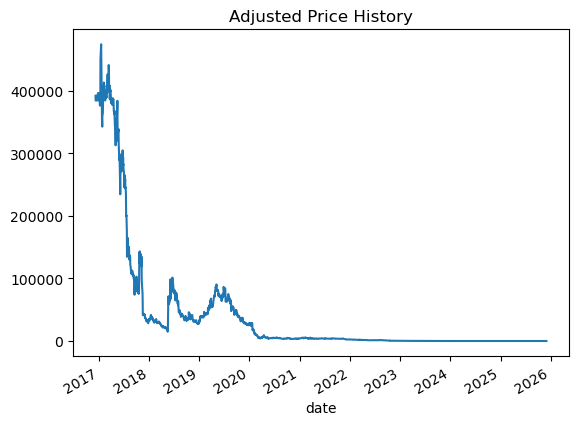

In [29]:
prc = price_df.set_index('date')['adjClose'].sort_index()
# vol = price_df.set_index('date')['volume'].sort_index()
prc.plot(label='price')
# vol.plot(label='volume')
plt.title('Adjusted Price History')
plt.show()

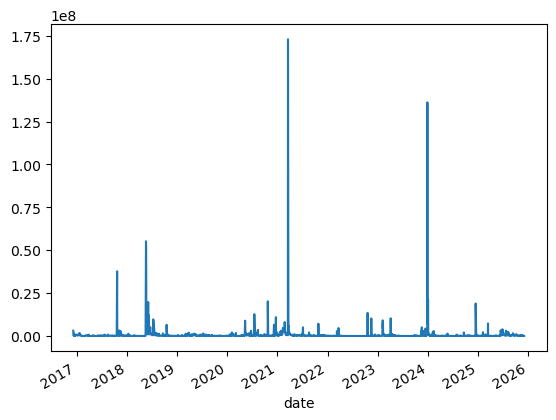

In [28]:
price_df.set_index('date')['price_X_volume'].sort_index().plot()
plt.show()

## Split Adjusted Price

In [39]:
price_full = getFMPData('historical-price-eod/full', symbol=symbol, from_='2000-01-01', to='2025-12-01')
len(price_full)

2257

In [40]:
price_full_df = pd.DataFrame(price_full)
price_full_df.head()

,symbol,date,open,high,low,close,volume,change,changePercent,vwap
0,SNES,2025-12-01,2.85,2.91,2.68,2.68,13615,-0.170,-5.96,2.7800
1,SNES,2025-11-28,2.86,2.92,2.83,2.91,17400,0.050,1.75,2.8800
2,SNES,2025-11-26,2.75,2.87,2.69,2.81,19200,0.060,2.18,2.7800
3,SNES,2025-11-25,2.78,2.96,2.72,2.88,77800,0.105,3.60,2.8350
4,SNES,2025-11-24,2.57,2.97,2.57,2.78,88832,0.210,8.17,2.7225


In [41]:
price_full_df.tail()

,symbol,date,open,high,low,close,volume,change,changePercent,vwap
2252,SNES,2016-12-14,386554.60,386554.60,384153.64,384153.64,4,-2400.96,-0.62112,385354.1200
2253,SNES,2016-12-13,384153.64,398554.59,357262.88,384153.64,1,0.00,0.00000,381031.1875
2254,SNES,2016-12-12,398559.40,398559.40,384153.64,384153.64,1,-14405.76,-3.61000,391356.5200
2255,SNES,2016-12-09,386554.60,407202.85,384153.64,384153.64,1,-2400.96,-0.62112,390516.1825
2256,SNES,2016-12-08,396158.44,409363.72,384153.64,391836.71,8,-4321.73,-1.09000,395378.1275


## Unadjusted Price

In [30]:
price_unadj = getFMPData('historical-price-eod/non-split-adjusted', symbol=symbol, from_='2000-01-01', to='2025-12-01')
len(price_unadj)

2257

In [31]:
price_unadj_df = pd.DataFrame(price_unadj)
price_unadj_df['date'] = pd.to_datetime(price_unadj_df['date'])
price_unadj_df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume
0,SNES,2025-12-01,2.85,2.91,2.68,2.68,13615
1,SNES,2025-11-28,2.86,2.92,2.83,2.91,17400
2,SNES,2025-11-26,2.75,2.87,2.69,2.81,19200
3,SNES,2025-11-25,2.78,2.96,2.72,2.88,77800
4,SNES,2025-11-24,2.57,2.97,2.57,2.78,88832


In [32]:
price_unadj_df.tail()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume
2252,SNES,2016-12-14,8.05,8.05,8.00,8.00,192000
2253,SNES,2016-12-13,8.00,8.30,7.44,8.00,48000
2254,SNES,2016-12-12,8.30,8.30,8.00,8.00,48000
2255,SNES,2016-12-09,8.05,8.48,8.00,8.00,48000
2256,SNES,2016-12-08,8.25,8.53,8.00,8.16,384000


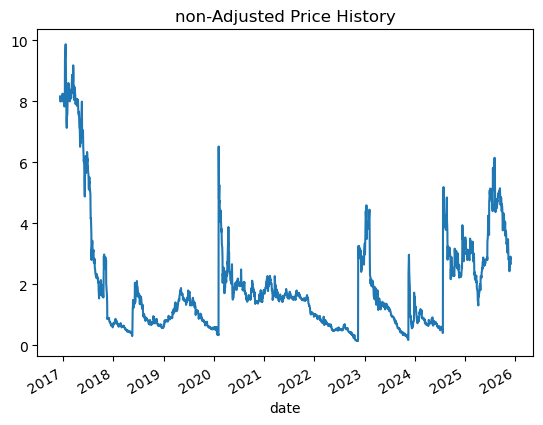

In [33]:
prc = price_unadj_df.set_index('date')['adjClose'].sort_index()

prc.plot(label='price')
plt.title('non-Adjusted Price History')
plt.show()

# Build Low Liquidity Filter

## Combine Price and Financial Statement

In [4]:
price_adj = getFMPData('historical-price-eod/dividend-adjusted', symbol=symbol, from_='2000-01-01', to='2025-12-01')
price_unadj = getFMPData('historical-price-eod/non-split-adjusted', symbol=symbol, from_='2000-01-01', to='2025-12-01')

price_adj_df = pd.DataFrame(price_adj)
price_unadj_df = pd.DataFrame(price_unadj)

price_adj_df['date'] = pd.to_datetime(price_adj_df['date'])
price_unadj_df['date'] = pd.to_datetime(price_unadj_df['date'])

price_adj_df.set_index('date', inplace=True)
price_unadj_df.set_index('date', inplace=True)

price_adj_df.shape, price_unadj_df.shape

((5642, 6), (5642, 6))

In [5]:
price_adj_df['rawVolume'] = price_unadj_df['volume']
price_adj_df['rawPrice'] = price_unadj_df['adjClose']
price_adj_df['dollarVolume'] = price_unadj_df['adjClose'] * price_unadj_df['volume']

In [6]:
price_adj_df = price_adj_df.sort_index()
price_adj_df

,symbol,adjOpen,adjHigh,adjLow,adjClose,volume,rawVolume,rawPrice,dollarVolume
date,,,,,,,,,
2003-07-01,CVCO,9.50,10.20,9.26,10.00,424600,212300,20.00,4.246000e+06
2003-07-02,CVCO,9.88,11.25,9.75,10.75,590200,295100,21.50,6.344650e+06
2003-07-03,CVCO,11.20,11.20,10.00,10.00,221200,110600,20.00,2.212000e+06
2003-07-07,CVCO,10.00,10.25,9.05,9.07,335800,167900,18.15,3.047385e+06
2003-07-08,CVCO,9.00,9.95,8.86,9.30,295000,147500,18.59,2.742025e+06
...,...,...,...,...,...,...,...,...,...
2025-11-24,CVCO,569.98,576.24,555.45,572.46,124700,124700,572.46,7.138576e+07
2025-11-25,CVCO,573.39,604.91,573.39,596.76,124264,124264,596.76,7.415578e+07
2025-11-26,CVCO,591.59,613.77,590.59,608.60,132220,132220,608.60,8.046909e+07


In [7]:
price_unadj_df = price_unadj_df.sort_index()
price_unadj_df

,symbol,adjOpen,adjHigh,adjLow,adjClose,volume
date,,,,,,
2003-07-01,CVCO,19.00,20.39,18.51,20.00,212300
2003-07-02,CVCO,19.75,22.50,19.50,21.50,295100
2003-07-03,CVCO,22.40,22.40,20.00,20.00,110600
2003-07-07,CVCO,20.00,20.50,18.10,18.15,167900
2003-07-08,CVCO,18.00,19.90,17.71,18.59,147500
...,...,...,...,...,...,...
2025-11-24,CVCO,569.98,576.24,555.45,572.46,124700
2025-11-25,CVCO,573.39,604.91,573.39,596.76,124264
2025-11-26,CVCO,591.59,613.77,590.59,608.60,132220


## SP500 Benchmark

In [26]:
sp500_adj = getFMPData('historical-price-eod/dividend-adjusted', symbol='SPY', from_='2000-01-01', to='2025-12-01')
sp500_adj_df = pd.DataFrame(sp500_adj)
sp500_adj_df['date'] = pd.to_datetime(sp500_adj_df['date'])
sp500_adj_df.set_index('date', inplace=True)
sp500_adj_df.sort_index(inplace=True)

sp500_adj_df

,symbol,adjOpen,adjHigh,adjLow,adjClose,volume
date,,,,,,
2000-01-03,SPY,93.67,93.67,90.90,91.89,8164300
2000-01-04,SPY,90.68,91.01,88.22,88.29,8089800
2000-01-05,SPY,88.41,89.42,86.71,88.45,12177900
2000-01-06,SPY,88.22,89.40,87.03,87.03,6227200
2000-01-07,SPY,88.65,92.09,88.49,92.09,8066500
...,...,...,...,...,...,...
2025-11-24,SPY,662.69,670.06,661.59,668.73,80437940
2025-11-25,SPY,668.63,676.21,664.48,675.02,81077100
2025-11-26,SPY,677.63,681.70,676.72,679.68,71879600


## Key Metrics

In [65]:
key_metrics_cols = key_metrics_df.columns.tolist()[4:]
# key_metrics_cols

In [67]:
key_metrics_cols = [
    'marketCap',
    'enterpriseValue',
    'evToSales',
    'evToOperatingCashFlow',
    # 'evToFreeCashFlow',
    'evToEBITDA',
    'netDebtToEBITDA',
    # 'currentRatio',
    'incomeQuality',
    # 'grahamNumber',
    # 'grahamNetNet',
    # 'taxBurden',
    # 'interestBurden',
    # 'workingCapital',
    # 'investedCapital',
    'returnOnAssets',
    # 'operatingReturnOnAssets',
    # 'returnOnTangibleAssets',
    'returnOnEquity',
    # 'returnOnInvestedCapital',
    # 'returnOnCapitalEmployed',
    'earningsYield',
    # 'freeCashFlowYield',
    # 'capexToOperatingCashFlow',
    # 'capexToDepreciation',
    # 'capexToRevenue',
    # 'salesGeneralAndAdministrativeToRevenue',
    # 'researchAndDevelopementToRevenue',
    # 'stockBasedCompensationToRevenue',
    # 'intangiblesToTotalAssets',
    # 'averageReceivables',
    # 'averagePayables',
    # 'averageInventory',
    # 'daysOfSalesOutstanding',
    # 'daysOfPayablesOutstanding',
    # 'daysOfInventoryOutstanding',
    # 'operatingCycle',
    # 'cashConversionCycle',
    # 'freeCashFlowToEquity',
    # 'freeCashFlowToFirm',
    # 'tangibleAssetValue',
    # 'netCurrentAssetValue'
]

In [98]:
key_metrics_slim_df = key_metrics_df[key_metrics_cols].sort_index()
# key_metrics_slim_df

## Enterprise Values

In [8]:
evalue = getFMPData('enterprise-values', symbol=symbol, limit=120, period='quarter')
len(evalue)

94

In [9]:
evalue_df = pd.DataFrame(evalue)
evalue_df['date'] = pd.to_datetime(evalue_df['date'])
evalue_df = evalue_df.set_index('date')

evalue_df.head(10)

,symbol,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue
date,,,,,,,
2025-09-27,CVCO,572.47,7931589,4540596754,374978000,30360000,4195978754
2025-06-28,CVCO,430.35,7953720,3422883402,344626000,37821000,3116078402
2025-03-29,CVCO,513.96,8121653,4174204775,356225000,45143000,3863122775
2024-12-28,CVCO,443.29,8097000,3589319130,362863000,39200000,3265656130
2024-09-28,CVCO,431.82,8226000,3552151320,364113000,40338000,3228376320
2024-06-29,CVCO,346.17,8286000,2868364620,359296000,47416000,2556484620
2024-03-30,CVCO,399.06,8338595,3327599720,352687000,48533000,3023445720
2023-12-30,CVCO,346.62,8358389,2897184795,352808000,46320000,2590696795
2023-09-30,CVCO,265.66,8656537,2299695619,377264000,30529000,1952960619


In [10]:
evalue_slim_df = evalue_df[[
    # 'stockPrice',
    'numberOfShares',
    'marketCapitalization'
]].sort_index()
evalue_slim_df

,numberOfShares,marketCapitalization
date,,
2002-06-30,6200000,62000000
2002-09-30,6200000,62000000
2002-12-31,6200000,62000000
2003-03-31,6200000,62000000
2003-06-30,6292990,62929900
2003-09-30,6292990,67429387
2003-12-31,6290860,75490320
2004-03-31,6288730,115869850
2004-06-30,6288730,124768403


In [11]:
cols = [
    'adjClose',
    'volume',
    'rawVolume',
    'dollarVolume',
    'evalues_missing',
    'numberOfShares',
    'marketCapitalization',
    'dollarVolume_tr30d',
    'price_tr30d',
    'turnOver_tr30d'
]

In [12]:
df1 = price_adj_df.join(evalue_slim_df.reindex(price_adj_df.index, method='ffill'))
df1['ipoDate'] = pd.to_datetime(stocks_df.loc[stocks_df['symbol']==symbol, 'ipoDate'].item())
df1['daysSinceIPO'] = (df1.index - df1['ipoDate']).dt.days
df1['eValuesDataMissing'] = (df1.index < evalue_slim_df.index.min()).astype(int)
df1['turnOver'] = df1['volume'] / df1['numberOfShares']
df1['dollarVolume_tr30d'] = df1.rolling(30)['dollarVolume'].mean()
df1['price_tr30d'] = df1.rolling(30)['adjClose'].mean()
df1['turnOver_tr30d'] = df1.rolling(30)['turnOver'].mean()
df1['lowLiquidity'] = np.where(
    (df1['marketCapitalization'] < 200000000) |
    (df1['dollarVolume_tr30d'] < 1000000) |
    (df1['price_tr30d'] < 2) |
    (df1['turnOver_tr30d'] < 0.0005), 1, 0
)


df1

,symbol,adjOpen,adjHigh,adjLow,adjClose,volume,rawVolume,rawPrice,dollarVolume,numberOfShares,marketCapitalization,ipoDate,daysSinceIPO,eValuesDataMissing,turnOver,dollarVolume_tr30d,price_tr30d,turnOver_tr30d,lowLiquidity
date,,,,,,,,,,,,,,,,,,,
2003-07-01,CVCO,9.50,10.20,9.26,10.00,424600,212300,20.00,4.246000e+06,6292990,62929900,2003-07-01,0,0,0.067472,NaN,NaN,NaN,1
2003-07-02,CVCO,9.88,11.25,9.75,10.75,590200,295100,21.50,6.344650e+06,6292990,62929900,2003-07-01,1,0,0.093787,NaN,NaN,NaN,1
2003-07-03,CVCO,11.20,11.20,10.00,10.00,221200,110600,20.00,2.212000e+06,6292990,62929900,2003-07-01,2,0,0.035150,NaN,NaN,NaN,1
2003-07-07,CVCO,10.00,10.25,9.05,9.07,335800,167900,18.15,3.047385e+06,6292990,62929900,2003-07-01,6,0,0.053361,NaN,NaN,NaN,1
2003-07-08,CVCO,9.00,9.95,8.86,9.30,295000,147500,18.59,2.742025e+06,6292990,62929900,2003-07-01,7,0,0.046878,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,CVCO,569.98,576.24,555.45,572.46,124700,124700,572.46,7.138576e+07,7931589,4540596754,2003-07-01,8182,0,0.015722,7.290205e+07,554.676000,0.016666,0
2025-11-25,CVCO,573.39,604.91,573.39,596.76,124264,124264,596.76,7.415578e+07,7931589,4540596754,2003-07-01,8183,0,0.015667,7.302469e+07,557.535667,0.016608,0
2025-11-26,CVCO,591.59,613.77,590.59,608.60,132220,132220,608.60,8.046909e+07,7931589,4540596754,2003-07-01,8184,0,0.016670,7.333172e+07,560.167000,0.016598,0


In [13]:
df1['lowLiquidity'].value_counts()

lowLiquidity
0    4102
1    1540
Name: count, dtype: int64

# Build Model Features

In [16]:
W1 = [1, 2, 3, 4, 5, 6, 7, 10, 15, 20, 25, 30, 45, 60, 90, 120]
W2 = [1, 2, 3, 5, 7, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]
W3 = [3, 5, 7, 10, 15, 20, 30, 60, 90, 120]

len(W1), len(W2), len(W3)

(16, 16, 10)

## Returns (RET)

In [30]:
retWindows = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60, 90, 120]

ret = pd.DataFrame(index=df1.index)
for w in retWindows:
    ser = np.log(1 + df1['adjClose'].pct_change(w))
    ser.name = f'ret_{w}'
    ret = pd.concat([ret, ser], axis=1)

ret

,ret_1,ret_2,ret_3,ret_5,ret_10,ret_15,ret_20,ret_30,ret_45,ret_60,ret_90,ret_120
date,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,0.072321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,-0.072321,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,-0.097613,-0.169933,-0.097613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,0.025042,-0.072571,-0.144891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,-0.001623,0.050700,0.053276,0.046848,-0.000838,0.066891,-0.027583,0.148724,0.020757,0.076142,0.307952,0.293955
2025-11-25,0.041572,0.039949,0.092272,0.101354,0.034574,0.117243,0.067120,0.155204,0.041747,0.128669,0.361238,0.342135
2025-11-26,0.019646,0.061218,0.059595,0.114494,0.079517,0.083314,0.188426,0.138926,0.078077,0.131515,0.357145,0.350567


## Moving Average of Returns (MAR)

In [39]:
retWindows = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60, 90, 120]
rollWindows = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60, 90, 120]

mar = pd.DataFrame(index=df1.index)
for i in rollWindows:
    for j in retWindows:
        ser = np.log(1 + df1['adjClose'].pct_change(j)).rolling(i).mean()
        ser.name = f'mar_{i}_{j}'
        mar = pd.concat([mar, ser], axis=1)

mar

,mar_1_1,mar_1_2,mar_1_3,mar_1_5,mar_1_10,mar_1_15,mar_1_20,mar_1_30,mar_1_45,mar_1_60,mar_1_90,mar_1_120,mar_2_1,mar_2_2,mar_2_3,mar_2_5,mar_2_10,mar_2_15,mar_2_20,mar_2_30,mar_2_45,mar_2_60,mar_2_90,mar_2_120,mar_3_1,mar_3_2,mar_3_3,mar_3_5,mar_3_10,mar_3_15,mar_3_20,mar_3_30,mar_3_45,mar_3_60,mar_3_90,mar_3_120,mar_5_1,mar_5_2,mar_5_3,mar_5_5,mar_5_10,mar_5_15,mar_5_20,mar_5_30,mar_5_45,mar_5_60,mar_5_90,mar_5_120,mar_10_1,mar_10_2,mar_10_3,mar_10_5,mar_10_10,mar_10_15,mar_10_20,mar_10_30,mar_10_45,mar_10_60,mar_10_90,mar_10_120,mar_15_1,mar_15_2,mar_15_3,mar_15_5,mar_15_10,mar_15_15,mar_15_20,mar_15_30,mar_15_45,mar_15_60,mar_15_90,mar_15_120,mar_20_1,mar_20_2,mar_20_3,mar_20_5,mar_20_10,mar_20_15,mar_20_20,mar_20_30,mar_20_45,mar_20_60,mar_20_90,mar_20_120,mar_30_1,mar_30_2,mar_30_3,mar_30_5,mar_30_10,mar_30_15,mar_30_20,mar_30_30,mar_30_45,mar_30_60,mar_30_90,mar_30_120,mar_45_1,mar_45_2,mar_45_3,mar_45_5,mar_45_10,mar_45_15,mar_45_20,mar_45_30,mar_45_45,mar_45_60,mar_45_90,mar_45_120,mar_60_1,mar_60_2,mar_60_3,mar_60_5,mar_60_10,mar_60_15,mar_60_20,mar_60_30,mar_60_45,mar_60_60,mar_60_90,mar_60_120,mar_90_1,mar_90_2,mar_90_3,mar_90_5,mar_90_10,mar_90_15,mar_90_20,mar_90_30,mar_90_45,mar_90_60,mar_90_90,mar_90_120,mar_120_1,mar_120_2,mar_120_3,mar_120_5,mar_120_10,mar_120_15,mar_120_20,mar_120_30,mar_120_45,mar_120_60,mar_120_90,mar_120_120
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,0.072321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,-0.072321,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.081668e-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,-0.097613,-0.169933,-0.097613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.496675e-02,-0.084967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.032538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,0.025042,-0.072571,-0.144891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [40]:
mar.isna().any(axis=1).sum()

239

In [41]:
mar.iloc[239:]

,mar_1_1,mar_1_2,mar_1_3,mar_1_5,mar_1_10,mar_1_15,mar_1_20,mar_1_30,mar_1_45,mar_1_60,mar_1_90,mar_1_120,mar_2_1,mar_2_2,mar_2_3,mar_2_5,mar_2_10,mar_2_15,mar_2_20,mar_2_30,mar_2_45,mar_2_60,mar_2_90,mar_2_120,mar_3_1,mar_3_2,mar_3_3,mar_3_5,mar_3_10,mar_3_15,mar_3_20,mar_3_30,mar_3_45,mar_3_60,mar_3_90,mar_3_120,mar_5_1,mar_5_2,mar_5_3,mar_5_5,mar_5_10,mar_5_15,mar_5_20,mar_5_30,mar_5_45,mar_5_60,mar_5_90,mar_5_120,mar_10_1,mar_10_2,mar_10_3,mar_10_5,mar_10_10,mar_10_15,mar_10_20,mar_10_30,mar_10_45,mar_10_60,mar_10_90,mar_10_120,mar_15_1,mar_15_2,mar_15_3,mar_15_5,mar_15_10,mar_15_15,mar_15_20,mar_15_30,mar_15_45,mar_15_60,mar_15_90,mar_15_120,mar_20_1,mar_20_2,mar_20_3,mar_20_5,mar_20_10,mar_20_15,mar_20_20,mar_20_30,mar_20_45,mar_20_60,mar_20_90,mar_20_120,mar_30_1,mar_30_2,mar_30_3,mar_30_5,mar_30_10,mar_30_15,mar_30_20,mar_30_30,mar_30_45,mar_30_60,mar_30_90,mar_30_120,mar_45_1,mar_45_2,mar_45_3,mar_45_5,mar_45_10,mar_45_15,mar_45_20,mar_45_30,mar_45_45,mar_45_60,mar_45_90,mar_45_120,mar_60_1,mar_60_2,mar_60_3,mar_60_5,mar_60_10,mar_60_15,mar_60_20,mar_60_30,mar_60_45,mar_60_60,mar_60_90,mar_60_120,mar_90_1,mar_90_2,mar_90_3,mar_90_5,mar_90_10,mar_90_15,mar_90_20,mar_90_30,mar_90_45,mar_90_60,mar_90_90,mar_90_120,mar_120_1,mar_120_2,mar_120_3,mar_120_5,mar_120_10,mar_120_15,mar_120_20,mar_120_30,mar_120_45,mar_120_60,mar_120_90,mar_120_120
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-06-14,-0.017289,-0.006456,-0.008929,0.003494,0.068032,0.107744,0.049014,0.001496,0.068032,0.054787,0.180828,0.545638,-0.003228,0.000952,-0.000778,0.010890,0.077477,0.125347,0.046277,0.011139,0.078012,0.062905,0.201557,0.557734,-0.002976,-0.000519,0.002798,0.019016,0.076481,0.127416,0.042266,0.008252,0.075773,0.062001,0.217319,0.556141,0.000699,0.004356,0.011410,0.037725,0.080089,0.118945,0.040038,0.008128,0.079664,0.061624,0.235071,0.559685,0.006803,0.015495,0.022944,0.040045,0.080654,0.060629,0.009574,-0.008593,0.073249,0.049991,0.233833,0.537981,0.007183,0.016713,0.025483,0.039648,0.040419,0.019335,-0.017604,-0.013641,0.047317,0.033979,0.241617,0.518353,0.002451,0.004628,0.006340,0.010010,0.004787,-0.013203,-0.039836,-0.020051,0.021157,0.010449,0.264169,0.497397,0.000050,0.000743,0.000825,0.001355,-0.002864,-0.006820,-0.013367,0.007171,0.030980,0.026185,0.347391,0.504415,0.001512,0.003467,0.005052,0.008852,0.016278,0.015772,0.009403,0.020654,0.037776,0.102542,0.408925,0.507469,0.000913,0.002097,0.003100,0.005135,0.008332,0.008495,0.003483,0.013092,0.076907,0.183203,0.422318,0.513845,0.002009,0.004479,0.007244,0.013059,0.025981,0.040270,0.058704,0.115797,0.204463,0.281545,0.449632,0.558596,0.004547,0.009296,0.013904,0.023320,0.044832,0.064794,0.082899,0.126104,0.190301,0.256923,0.418947,0.505432
2004-06-15,-0.005997,-0.023286,-0.012453,-0.015913,0.050370,0.075458,0.075999,0.009064,0.043541,0.046162,0.114031,0.550882,-0.011643,-0.014871,-0.010691,-0.006209,0.059201,0.091601,0.062507,0.005280,0.055787,0.050475,0.147429,0.548260,-0.004151,-0.007127,-0.004670,0.001956,0.068442,0.108717,0.056184,0.010447,0.066522,0.057324,0.172382,0.555450,-0.003183,-0.002484,0.001173,0.021286,0.071889,0.115654,0.047697,0.007258,0.072249,0.058231,0.205503,0.557371,0.005037,0.011840,0.020533,0.035945,0.083128,0.071033,0.021305,-0.002399,0.075094,0.051990,0.218434,0.543278,0.005031,0.012213,0.021743,0.038551,0.047355,0.028792,-0.007340,-0.010908,0.052173,0.038022,0.230256,0.524817,0.003800,0.006251,0.008428,0.011924,0.010652,-0.005505,-0.032111,-0.019033,0.024774,0.015417,0.249489,0.501845,0.000302,0.000352,0.001045,0.001210,-0.000800,-0.005454,-0.012688,0.006236,0.030702,0.024225,0.333132,0.505434,0.000968,0.002479,0.004435,0.008028,0.016688,0.017391,0.011011,0.020468,0.037177,0.096538,0.400663,0.507909,0.000769,0.001682,0.002866,0.004853,0.008665,0.009506,0.005139,0.012112,0.072403,0.175560,0.416165,0.512533,0.001267,0.003276,0.005746,0.011417,0.024270,0

In [42]:
mar_df = mar.iloc[239:]
mar_df.shape

(5403, 144)

In [43]:
mar_df.isna().sum().sum()

0

In [44]:
mar_arr = mar.iloc[239:].values.reshape(-1, 12, 12)
mar_arr.shape

(5403, 12, 12)

In [45]:
mar_arr[-1].shape

(12, 12)

In [46]:
np.round(mar_arr[-1], 3)

array([[-0.019, -0.041, -0.021,  0.019,  0.046,  0.013,  0.098,  0.052,
         0.02 ,  0.068,  0.349,  0.307],
       [-0.02 , -0.021,  0.009,  0.055,  0.063,  0.025,  0.132,  0.075,
         0.043,  0.069,  0.35 ,  0.322],
       [-0.007,  0.006,  0.026,  0.075,  0.068,  0.045,  0.151,  0.096,
         0.055,  0.09 ,  0.352,  0.332],
       [ 0.004,  0.022,  0.045,  0.074,  0.048,  0.064,  0.099,  0.118,
         0.045,  0.095,  0.345,  0.326],
       [ 0.005,  0.013,  0.02 ,  0.024,  0.018,  0.044,  0.021,  0.1  ,
         0.017,  0.071,  0.285,  0.284],
       [ 0.001,  0.003,  0.009,  0.021,  0.029,  0.019,  0.038,  0.056,
         0.023,  0.097,  0.266,  0.235],
       [ 0.005,  0.013,  0.023,  0.025,  0.01 ,  0.028,  0.051,  0.037,
         0.025,  0.114,  0.257,  0.191],
       [ 0.002,  0.005,  0.01 ,  0.02 ,  0.033,  0.028,  0.025,  0.03 ,
         0.05 ,  0.166,  0.275,  0.155],
       [ 0.   ,  0.002,  0.004,  0.005,  0.004,  0.008,  0.011,  0.034,
         0.1  ,  0.181, 

## Moving Volatility (MAS)

In [48]:
retWindows = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60, 90, 120]
rollWindows = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60, 90, 120]

mas = pd.DataFrame(index=df1.index)
for i in rollWindows:
    for j in retWindows:
        ser = np.log(1 + df1['adjClose'].pct_change(j)).rolling(i).std()
        ser.name = f'mas_{i}_{j}'
        mas = pd.concat([mas, ser], axis=1)

mas

,mas_1_1,mas_1_2,mas_1_3,mas_1_5,mas_1_10,mas_1_15,mas_1_20,mas_1_30,mas_1_45,mas_1_60,mas_1_90,mas_1_120,mas_2_1,mas_2_2,mas_2_3,mas_2_5,mas_2_10,mas_2_15,mas_2_20,mas_2_30,mas_2_45,mas_2_60,mas_2_90,mas_2_120,mas_3_1,mas_3_2,mas_3_3,mas_3_5,mas_3_10,mas_3_15,mas_3_20,mas_3_30,mas_3_45,mas_3_60,mas_3_90,mas_3_120,mas_5_1,mas_5_2,mas_5_3,mas_5_5,mas_5_10,mas_5_15,mas_5_20,mas_5_30,mas_5_45,mas_5_60,mas_5_90,mas_5_120,mas_10_1,mas_10_2,mas_10_3,mas_10_5,mas_10_10,mas_10_15,mas_10_20,mas_10_30,mas_10_45,mas_10_60,mas_10_90,mas_10_120,mas_15_1,mas_15_2,mas_15_3,mas_15_5,mas_15_10,mas_15_15,mas_15_20,mas_15_30,mas_15_45,mas_15_60,mas_15_90,mas_15_120,mas_20_1,mas_20_2,mas_20_3,mas_20_5,mas_20_10,mas_20_15,mas_20_20,mas_20_30,mas_20_45,mas_20_60,mas_20_90,mas_20_120,mas_30_1,mas_30_2,mas_30_3,mas_30_5,mas_30_10,mas_30_15,mas_30_20,mas_30_30,mas_30_45,mas_30_60,mas_30_90,mas_30_120,mas_45_1,mas_45_2,mas_45_3,mas_45_5,mas_45_10,mas_45_15,mas_45_20,mas_45_30,mas_45_45,mas_45_60,mas_45_90,mas_45_120,mas_60_1,mas_60_2,mas_60_3,mas_60_5,mas_60_10,mas_60_15,mas_60_20,mas_60_30,mas_60_45,mas_60_60,mas_60_90,mas_60_120,mas_90_1,mas_90_2,mas_90_3,mas_90_5,mas_90_10,mas_90_15,mas_90_20,mas_90_30,mas_90_45,mas_90_60,mas_90_90,mas_90_120,mas_120_1,mas_120_2,mas_120_3,mas_120_5,mas_120_10,mas_120_15,mas_120_20,mas_120_30,mas_120_45,mas_120_60,mas_120_90,mas_120_120
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.102277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017884,0.120161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.091686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.086730,0.068846,0.033431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [50]:
mas.loc[:, 'mas_2_1':].iloc[239:]

,mas_2_1,mas_2_2,mas_2_3,mas_2_5,mas_2_10,mas_2_15,mas_2_20,mas_2_30,mas_2_45,mas_2_60,mas_2_90,mas_2_120,mas_3_1,mas_3_2,mas_3_3,mas_3_5,mas_3_10,mas_3_15,mas_3_20,mas_3_30,mas_3_45,mas_3_60,mas_3_90,mas_3_120,mas_5_1,mas_5_2,mas_5_3,mas_5_5,mas_5_10,mas_5_15,mas_5_20,mas_5_30,mas_5_45,mas_5_60,mas_5_90,mas_5_120,mas_10_1,mas_10_2,mas_10_3,mas_10_5,mas_10_10,mas_10_15,mas_10_20,mas_10_30,mas_10_45,mas_10_60,mas_10_90,mas_10_120,mas_15_1,mas_15_2,mas_15_3,mas_15_5,mas_15_10,mas_15_15,mas_15_20,mas_15_30,mas_15_45,mas_15_60,mas_15_90,mas_15_120,mas_20_1,mas_20_2,mas_20_3,mas_20_5,mas_20_10,mas_20_15,mas_20_20,mas_20_30,mas_20_45,mas_20_60,mas_20_90,mas_20_120,mas_30_1,mas_30_2,mas_30_3,mas_30_5,mas_30_10,mas_30_15,mas_30_20,mas_30_30,mas_30_45,mas_30_60,mas_30_90,mas_30_120,mas_45_1,mas_45_2,mas_45_3,mas_45_5,mas_45_10,mas_45_15,mas_45_20,mas_45_30,mas_45_45,mas_45_60,mas_45_90,mas_45_120,mas_60_1,mas_60_2,mas_60_3,mas_60_5,mas_60_10,mas_60_15,mas_60_20,mas_60_30,mas_60_45,mas_60_60,mas_60_90,mas_60_120,mas_90_1,mas_90_2,mas_90_3,mas_90_5,mas_90_10,mas_90_15,mas_90_20,mas_90_30,mas_90_45,mas_90_60,mas_90_90,mas_90_120,mas_120_1,mas_120_2,mas_120_3,mas_120_5,mas_120_10,mas_120_15,mas_120_20,mas_120_30,mas_120_45,mas_120_60,mas_120_90,mas_120_120
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004-06-14,0.019884,0.010477,0.011527,0.010459,0.013357,0.024895,0.003871,0.013638,0.014113,0.011481,0.029316,0.017106,0.014067,0.007834,0.010237,0.015900,0.009601,0.017964,0.007468,0.010863,0.010707,0.008268,0.034278,0.012406,0.012255,0.008690,0.017179,0.027980,0.009366,0.019963,0.006139,0.008601,0.009881,0.006049,0.034327,0.010186,0.014203,0.017557,0.021804,0.024633,0.027412,0.066649,0.036633,0.025759,0.027213,0.016067,0.032236,0.030385,0.012883,0.017914,0.021466,0.023246,0.063236,0.080724,0.049544,0.023096,0.044691,0.027707,0.031604,0.038439,0.016930,0.030469,0.041882,0.057163,0.084068,0.090709,0.058604,0.024587,0.060820,0.048511,0.055241,0.050387,0.015172,0.026096,0.035514,0.048257,0.069532,0.076897,0.062951,0.045037,0.052610,0.054095,0.128576,0.042898,0.014432,0.022987,0.030960,0.042020,0.063451,0.073116,0.064923,0.043131,0.046290,0.120558,0.137221,0.035349,0.014477,0.021983,0.028974,0.039188,0.058034,0.065219,0.057415,0.045488,0.085868,0.177069,0.121036,0.040483,0.019399,0.027336,0.034766,0.045739,0.072916,0.094467,0.118066,0.167188,0.196312,0.201819,0.109441,0.074857,0.022670,0.031740,0.039571,0.049557,0.080738,0.105984,0.126414,0.160293,0.184031,0.184704,0.124887,0.130552
2004-06-15,0.007984,0.011900,0.002492,0.013723,0.012489,0.022829,0.019081,0.005351,0.017318,0.006099,0.047233,0.003708,0.014151,0.015834,0.010577,0.017151,0.018279,0.033756,0.017377,0.009718,0.022264,0.012624,0.054620,0.012726,0.010107,0.014047,0.010952,0.030991,0.013880,0.025982,0.016920,0.008141,0.018838,0.009022,0.059738,0.010701,0.014623,0.021446,0.024373,0.030186,0.022585,0.058839,0.037305,0.020921,0.024023,0.013866,0.047334,0.027058,0.012138,0.018961,0.022914,0.025502,0.057637,0.078234,0.052032,0.023203,0.039418,0.024351,0.043500,0.034811,0.014913,0.027835,0.039688,0.055516,0.082884,0.091406,0.063239,0.025377,0.059836,0.046705,0.054110,0.051014,0.015000,0.026373,0.035407,0.048304,0.070181,0.078012,0.063825,0.044684,0.052518,0.052173,0.129984,0.043645,0.014237,0.023163,0.031027,0.042137,0.063614,0.073623,0.065669,0.043163,0.046031,0.116321,0.143533,0.035770,0.014503,0.022226,0.029043,0.039279,0.058220,0.065786,0.058057,0.044918,0.080130,0.172801,0.127119,0.037859,0.018375,0.026109,0.032586,0.044045,0.070449,0.091975,0.113341,0.164009,0.195735,0.202818,0.114353,0.074842,0.022644,0.031855,0.039583,0.049622,0.080621,0.105689,0.126108,0.160081,0.183890,0.185316,0.124706,0.126197
2004-06-16,0.007776,0.015760,0.004124,0.004234,0.003536,0.004068,0.024494,0.001809,0.016613,0.007630,0.005923,0.008052,0.011145,0.011618,0.004726,0.009938,0.009104,0.020503,0.030891,0.003849,0.013861,0

## Moving Average Prices (MAP)

In [32]:
MAPriceWindows = [3, 5, 7, 10, 15, 20, 30, 50, 60, 90, 100, 120]

In [51]:
maprice = pd.DataFrame(index=df1.index)
for w in MAPriceWindows:
    ser = df1['adjClose'].rolling(w).mean()
    ser.name = f'map_{w}'
    maprice = pd.concat([maprice, ser], axis=1)

maprice

,map_3,map_5,map_7,map_10,map_15,map_20,map_30,map_50,map_60,map_90,map_100,map_120
date,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,10.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,9.940000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,9.456667,9.824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,563.336667,554.402,553.748571,556.501,558.596667,550.5135,554.676000,552.6448,551.071000,521.486444,513.3589,498.333833
2025-11-25,580.870000,565.906,559.290000,558.529,562.998000,552.4505,557.535667,553.3818,552.271833,523.496778,514.8550,499.774750
2025-11-26,592.606667,579.074,568.195714,563.181,566.241333,557.6765,560.167000,554.5394,553.521833,525.527667,516.4733,501.274500


## Average True Range (ATR)

In [52]:
tr = np.maximum(df1['adjHigh'] - df1['adjLow'], np.abs(df1['adjHigh'] - df1['adjClose'].shift(1)), np.abs(df1['adjLow'] - df1['adjClose'].shift(1)))
matr = pd.DataFrame(index=df1.index)
for w in MAPriceWindows:
    ser = tr.rolling(w).mean()
    ser.name = f"matr_{w}"
    matr = pd.concat([matr, ser], axis=1)

matr

,matr_3,matr_5,matr_7,matr_10,matr_15,matr_20,matr_30,matr_50,matr_60,matr_90,matr_100,matr_120
date,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,1.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,1.163333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,24.390000,20.412,20.490000,18.808,21.544000,27.5905,25.480667,23.9458,22.422167,19.770222,19.1760,18.353167
2025-11-25,29.460000,23.790,21.961429,20.891,22.107333,27.5550,25.663000,24.1034,22.874167,20.001222,19.3362,18.526083
2025-11-26,25.473333,25.760,22.527143,21.216,20.634000,26.0635,25.382000,24.0402,23.072500,20.070444,19.4767,18.612000


## Daily Volatility (Sigma)

In [53]:
sigma = pd.DataFrame(index=df1.index)
for w in MAPriceWindows:
    ser = ret['ret_1'].rolling(w).std()
    ser.name = f'sigma_{w}'
    sigma = pd.concat([sigma, ser], axis=1)

sigma

,sigma_3,sigma_5,sigma_7,sigma_10,sigma_15,sigma_20,sigma_30,sigma_50,sigma_60,sigma_90,sigma_100,sigma_120
date,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,0.091686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,0.064760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,0.030007,0.025088,0.023728,0.022939,0.023972,0.035591,0.031777,0.033793,0.031677,0.028902,0.028062,0.027275
2025-11-25,0.028553,0.024814,0.027354,0.026472,0.025465,0.034630,0.032010,0.034094,0.032057,0.029133,0.028220,0.027494
2025-11-26,0.021599,0.023661,0.023813,0.024811,0.022437,0.024373,0.031606,0.034092,0.032081,0.029105,0.028267,0.027526


## Moving Average Price Delta (MAPD)

In [54]:
W = [0] + MAPriceWindows

mapd = pd.DataFrame(index=df1.index)
for i in range(len(W)):
    for j in range(i + 1, len(W)):
        if i == 0:
            short = df1['adjClose']
        else:
            short = df1['adjClose'].rolling(W[i]).mean()
        long = df1['adjClose'].rolling(W[j]).mean()
        ser = short - long
        ser.name = f"mapd_{W[i]}_{W[j]}"
        mapd = pd.concat([mapd, ser], axis=1)

mapd

,mapd_0_3,mapd_0_5,mapd_0_7,mapd_0_10,mapd_0_15,mapd_0_20,mapd_0_30,mapd_0_50,mapd_0_60,mapd_0_90,mapd_0_100,mapd_0_120,mapd_3_5,mapd_3_7,mapd_3_10,mapd_3_15,mapd_3_20,mapd_3_30,mapd_3_50,mapd_3_60,mapd_3_90,mapd_3_100,mapd_3_120,mapd_5_7,mapd_5_10,mapd_5_15,mapd_5_20,mapd_5_30,mapd_5_50,mapd_5_60,mapd_5_90,mapd_5_100,mapd_5_120,mapd_7_10,mapd_7_15,mapd_7_20,mapd_7_30,mapd_7_50,mapd_7_60,mapd_7_90,mapd_7_100,mapd_7_120,mapd_10_15,mapd_10_20,mapd_10_30,mapd_10_50,mapd_10_60,mapd_10_90,mapd_10_100,mapd_10_120,mapd_15_20,mapd_15_30,mapd_15_50,mapd_15_60,mapd_15_90,mapd_15_100,mapd_15_120,mapd_20_30,mapd_20_50,mapd_20_60,mapd_20_90,mapd_20_100,mapd_20_120,mapd_30_50,mapd_30_60,mapd_30_90,mapd_30_100,mapd_30_120,mapd_50_60,mapd_50_90,mapd_50_100,mapd_50_120,mapd_60_90,mapd_60_100,mapd_60_120,mapd_90_100,mapd_90_120,mapd_100_120
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,-0.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,-0.870000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,-0.156667,-0.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.367333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,9.123333,18.058,18.711429,15.959,13.863333,21.9465,17.784000,19.8152,21.389000,50.973556,59.1011,74.126167,8.934667,9.588095,6.835667,4.740000,12.823167,8.660667,10.691867,12.265667,41.850222,49.977767,65.002833,0.653429,-2.099,-4.194667,3.8885,-0.274000,1.7572,3.331000,32.915556,41.0431,56.068167,-2.752429,-4.848095,3.235071,-0.927429,1.103771,2.677571,32.262127,40.389671,55.414738,-2.095667,5.9875,1.825000,3.8562,5.430000,35.014556,43.1421,58.167167,8.083167,3.920667,5.951867,7.525667,37.110222,45.237767,60.262833,-4.162500,-2.1313,-0.557500,29.027056,37.1546,52.179667,2.031200,3.605000,33.189556,41.317100,56.342167,1.573800,31.158356,39.2859,54.310967,29.584556,37.712100,52.737167,8.127544,23.152611,15.025067
2025-11-25,15.890000,30.854,37.470000,38.231,33.762000,44.3095,39.224333,43.3782,44.488167,73.263222,81.9050,96.985250,14.964000,21.580000,22.341000,17.872000,28.419500,23.334333,27.488200,28.598167,57.373222,66.015000,81.095250,6.616000,7.377,2.908000,13.4555,8.370333,12.5242,13.634167,42.409222,51.0510,66.131250,0.761000,-3.708000,6.839500,1.754333,5.908200,7.018167,35.793222,44.435000,

## Moving Average Log Price Delta (MAPDLN)

In [61]:
W = [0] + MAPriceWindows

mapdln = pd.DataFrame(index=df1.index)
for i in range(len(W)):
    for j in range(i + 1, len(W)):
        if i == 0:
            short = df1['adjClose']
        else:
            short = df1['adjClose'].rolling(W[i]).mean()
        long = df1['adjClose'].rolling(W[j]).mean()
        ser = np.log(short + epsilon) - np.log(long + epsilon)
        ser.name = f"mapd_{W[i]}_{W[j]}"
        mapdln = pd.concat([mapdln, ser], axis=1)

mapdln

,mapd_0_3,mapd_0_5,mapd_0_7,mapd_0_10,mapd_0_15,mapd_0_20,mapd_0_30,mapd_0_50,mapd_0_60,mapd_0_90,mapd_0_100,mapd_0_120,mapd_3_5,mapd_3_7,mapd_3_10,mapd_3_15,mapd_3_20,mapd_3_30,mapd_3_50,mapd_3_60,mapd_3_90,mapd_3_100,mapd_3_120,mapd_5_7,mapd_5_10,mapd_5_15,mapd_5_20,mapd_5_30,mapd_5_50,mapd_5_60,mapd_5_90,mapd_5_100,mapd_5_120,mapd_7_10,mapd_7_15,mapd_7_20,mapd_7_30,mapd_7_50,mapd_7_60,mapd_7_90,mapd_7_100,mapd_7_120,mapd_10_15,mapd_10_20,mapd_10_30,mapd_10_50,mapd_10_60,mapd_10_90,mapd_10_100,mapd_10_120,mapd_15_20,mapd_15_30,mapd_15_50,mapd_15_60,mapd_15_90,mapd_15_100,mapd_15_120,mapd_20_30,mapd_20_50,mapd_20_60,mapd_20_90,mapd_20_100,mapd_20_120,mapd_30_50,mapd_30_60,mapd_30_90,mapd_30_100,mapd_30_120,mapd_50_60,mapd_50_90,mapd_50_100,mapd_50_120,mapd_60_90,mapd_60_100,mapd_60_120,mapd_90_100,mapd_90_120,mapd_100_120
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,-0.024693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,-0.091595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,-0.016706,-0.054814,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.038108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,0.016065,0.032053,0.033232,0.028274,0.024515,0.039091,0.031559,0.035227,0.038079,0.093260,0.108968,0.138673,0.015987,0.017167,0.012208,0.008450,0.023026,0.015493,0.019162,0.022014,0.077194,0.092902,0.122607,0.001179,-0.003779,-0.007538,0.007039,-0.000494,0.003175,0.006026,0.061207,0.076915,0.106620,-0.004958,-0.008717,0.005859,-0.001673,0.001995,0.004847,0.060027,0.075736,0.105441,-0.003759,0.010817,0.003285,0.006953,0.009805,0.064986,0.080694,0.110399,0.014576,0.007044,0.010712,0.013564,0.068744,0.084452,0.114157,-0.007533,-0.003864,-0.001012,0.054168,0.069876,0.099581,0.003669,0.006521,0.061701,0.077409,0.107114,0.002852,0.058032,0.073740,0.103445,0.055180,0.070888,0.100593,0.015708,0.045413,0.029705
2025-11-25,0.026988,0.053087,0.064847,0.066208,0.058239,0.077151,0.067989,0.075467,0.077475,0.130984,0.147630,0.177358,0.026099,0.037859,0.039220,0.031251,0.050163,0.041001,0.048479,0.050487,0.103996,0.120642,0.150369,0.011760,0.013121,0.005152,0.024064,0.014902,0.022380,0.024388,0.077897,0.094543,0.124270,0.001362,-0.006608,0.012304,0.003142,0.010620,0.012628,0.066137,0.082783,0.112511,-0.00797

## MAPD-MA

In [81]:
mapd_ma = pd.DataFrame(index=df1.index)

for col in mapd.columns:
    i, j = col.split('_')[-2], col.split('_')[-1]
    _col = f'map_{j}'
    ser = mapd[col] / (maprice[_col] + epsilon)
    ser.name = f"mapd_ma_{i}_{j}"
    mapd_ma = pd.concat([mapd_ma, ser], axis=1)

mapd_ma

,mapd_ma_0_3,mapd_ma_0_5,mapd_ma_0_7,mapd_ma_0_10,mapd_ma_0_15,mapd_ma_0_20,mapd_ma_0_30,mapd_ma_0_50,mapd_ma_0_60,mapd_ma_0_90,mapd_ma_0_100,mapd_ma_0_120,mapd_ma_3_5,mapd_ma_3_7,mapd_ma_3_10,mapd_ma_3_15,mapd_ma_3_20,mapd_ma_3_30,mapd_ma_3_50,mapd_ma_3_60,mapd_ma_3_90,mapd_ma_3_100,mapd_ma_3_120,mapd_ma_5_7,mapd_ma_5_10,mapd_ma_5_15,mapd_ma_5_20,mapd_ma_5_30,mapd_ma_5_50,mapd_ma_5_60,mapd_ma_5_90,mapd_ma_5_100,mapd_ma_5_120,mapd_ma_7_10,mapd_ma_7_15,mapd_ma_7_20,mapd_ma_7_30,mapd_ma_7_50,mapd_ma_7_60,mapd_ma_7_90,mapd_ma_7_100,mapd_ma_7_120,mapd_ma_10_15,mapd_ma_10_20,mapd_ma_10_30,mapd_ma_10_50,mapd_ma_10_60,mapd_ma_10_90,mapd_ma_10_100,mapd_ma_10_120,mapd_ma_15_20,mapd_ma_15_30,mapd_ma_15_50,mapd_ma_15_60,mapd_ma_15_90,mapd_ma_15_100,mapd_ma_15_120,mapd_ma_20_30,mapd_ma_20_50,mapd_ma_20_60,mapd_ma_20_90,mapd_ma_20_100,mapd_ma_20_120,mapd_ma_30_50,mapd_ma_30_60,mapd_ma_30_90,mapd_ma_30_100,mapd_ma_30_120,mapd_ma_50_60,mapd_ma_50_90,mapd_ma_50_100,mapd_ma_50_120,mapd_ma_60_90,mapd_ma_60_100,mapd_ma_60_120,mapd_ma_90_100,mapd_ma_90_120,mapd_ma_100_120
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,-0.024390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,-0.087525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,-0.016567,-0.053339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.037391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,0.016195,0.032572,0.033790,0.028677,0.024818,0.039866,0.032062,0.035855,0.038814,0.097747,0.115126,0.148748,0.016116,0.017315,0.012283,0.008486,0.023293,0.015614,0.019347,0.022258,0.080252,0.097354,0.130440,0.001180,-0.003772,-0.007509,0.007063,-0.000494,0.003180,0.006045,0.063119,0.079950,0.112511,-0.004946,-0.008679,0.005876,-0.001672,0.001997,0.004859,0.061866,0.078677,0.111200,-0.003752,0.010876,0.003290,0.006978,0.009854,0.067144,0.084039,0.116723,0.014683,0.007068,0.010770,0.013656,0.071162,0.088121,0.120929,-0.007504,-0.003857,-0.001012,0.055662,0.072375,0.104708,0.003675,0.006542,0.063644,0.080484,0.113061,0.002856,0.059749,0.076527,0.108985,0.056731,0.073461,0.105827,0.015832,0.046460,0.030151
2025-11-25,0.027356,0.054521,0.066996,0.068449,0.059968,0.080205,0.070353,0.078387,0.080555,0.139950,0.159084,0.194058,0.026443,0.038585,0.040000,0.031744,0.051443,

## MAPD-ATR

In [82]:
mapd_atr = pd.DataFrame(index=df1.index)

for col in mapd.columns:
    i, j = col.split('_')[-2], col.split('_')[-1]
    _col = f'matr_{j}'
    ser = mapd[col] / (matr[_col] + epsilon)
    ser.name = f"mapd_atr_{i}_{j}"
    mapd_atr = pd.concat([mapd_atr, ser], axis=1)

mapd_atr

,mapd_atr_0_3,mapd_atr_0_5,mapd_atr_0_7,mapd_atr_0_10,mapd_atr_0_15,mapd_atr_0_20,mapd_atr_0_30,mapd_atr_0_50,mapd_atr_0_60,mapd_atr_0_90,mapd_atr_0_100,mapd_atr_0_120,mapd_atr_3_5,mapd_atr_3_7,mapd_atr_3_10,mapd_atr_3_15,mapd_atr_3_20,mapd_atr_3_30,mapd_atr_3_50,mapd_atr_3_60,mapd_atr_3_90,mapd_atr_3_100,mapd_atr_3_120,mapd_atr_5_7,mapd_atr_5_10,mapd_atr_5_15,mapd_atr_5_20,mapd_atr_5_30,mapd_atr_5_50,mapd_atr_5_60,mapd_atr_5_90,mapd_atr_5_100,mapd_atr_5_120,mapd_atr_7_10,mapd_atr_7_15,mapd_atr_7_20,mapd_atr_7_30,mapd_atr_7_50,mapd_atr_7_60,mapd_atr_7_90,mapd_atr_7_100,mapd_atr_7_120,mapd_atr_10_15,mapd_atr_10_20,mapd_atr_10_30,mapd_atr_10_50,mapd_atr_10_60,mapd_atr_10_90,mapd_atr_10_100,mapd_atr_10_120,mapd_atr_15_20,mapd_atr_15_30,mapd_atr_15_50,mapd_atr_15_60,mapd_atr_15_90,mapd_atr_15_100,mapd_atr_15_120,mapd_atr_20_30,mapd_atr_20_50,mapd_atr_20_60,mapd_atr_20_90,mapd_atr_20_100,mapd_atr_20_120,mapd_atr_30_50,mapd_atr_30_60,mapd_atr_30_90,mapd_atr_30_100,mapd_atr_30_120,mapd_atr_50_60,mapd_atr_50_90,mapd_atr_50_100,mapd_atr_50_120,mapd_atr_60_90,mapd_atr_60_100,mapd_atr_60_120,mapd_atr_90_100,mapd_atr_90_120,mapd_atr_100_120
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,-0.669230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,-0.134670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,0.374060,0.884676,0.913198,0.848522,0.643489,0.795437,0.697941,0.827502,0.953922,2.578299,3.082035,4.038876,0.437716,0.467940,0.363445,0.220015,0.464767,0.339892,0.446503,0.547033,2.116831,2.606266,3.541777,0.031890,-0.111601,-0.194702,0.140936,-0.010753,0.073382,0.148558,1.664906,2.140337,3.054959,-0.146343,-0.225032,0.117253,-0.036397,0.046095,0.119416,1.631854,2.106261,3.019356,-0.097274,0.217013,0.071623,0.161039,0.242171,1.771075,2.249797,3.169326,0.292969,0.153868,0.248556,0.335635,1.877077,2.359082,3.283511,-0.163359,-0.089005,-0.024864,1.468221,1.937557,2.843088,0.084825,0.160778,1.678765,2.154625,3.069888,0.070189,1.576024,2.048701,2.959215,1.496420,1.966630,2.873464,0.423839,1.261505,0.818663
2025-11-25,0.539375,1.296931,1.706173,1.830022,1.527185,1.608038,1.528439,1.799671,1.944909,3.662937,4.2

## MAPDLN-Sigma

In [83]:
mapdln_sigma = pd.DataFrame(index=df1.index)

for col in mapdln.columns:
    i, j = col.split('_')[-2], col.split('_')[-1]
    _col = f'sigma_{j}'
    ser = mapdln[col] / (sigma[_col] + epsilon)
    ser.name = f"mapdln_sigma_{i}_{j}"
    mapdln_sigma = pd.concat([mapdln_sigma, ser], axis=1)

mapdln_sigma

,mapdln_sigma_0_3,mapdln_sigma_0_5,mapdln_sigma_0_7,mapdln_sigma_0_10,mapdln_sigma_0_15,mapdln_sigma_0_20,mapdln_sigma_0_30,mapdln_sigma_0_50,mapdln_sigma_0_60,mapdln_sigma_0_90,mapdln_sigma_0_100,mapdln_sigma_0_120,mapdln_sigma_3_5,mapdln_sigma_3_7,mapdln_sigma_3_10,mapdln_sigma_3_15,mapdln_sigma_3_20,mapdln_sigma_3_30,mapdln_sigma_3_50,mapdln_sigma_3_60,mapdln_sigma_3_90,mapdln_sigma_3_100,mapdln_sigma_3_120,mapdln_sigma_5_7,mapdln_sigma_5_10,mapdln_sigma_5_15,mapdln_sigma_5_20,mapdln_sigma_5_30,mapdln_sigma_5_50,mapdln_sigma_5_60,mapdln_sigma_5_90,mapdln_sigma_5_100,mapdln_sigma_5_120,mapdln_sigma_7_10,mapdln_sigma_7_15,mapdln_sigma_7_20,mapdln_sigma_7_30,mapdln_sigma_7_50,mapdln_sigma_7_60,mapdln_sigma_7_90,mapdln_sigma_7_100,mapdln_sigma_7_120,mapdln_sigma_10_15,mapdln_sigma_10_20,mapdln_sigma_10_30,mapdln_sigma_10_50,mapdln_sigma_10_60,mapdln_sigma_10_90,mapdln_sigma_10_100,mapdln_sigma_10_120,mapdln_sigma_15_20,mapdln_sigma_15_30,mapdln_sigma_15_50,mapdln_sigma_15_60,mapdln_sigma_15_90,mapdln_sigma_15_100,mapdln_sigma_15_120,mapdln_sigma_20_30,mapdln_sigma_20_50,mapdln_sigma_20_60,mapdln_sigma_20_90,mapdln_sigma_20_100,mapdln_sigma_20_120,mapdln_sigma_30_50,mapdln_sigma_30_60,mapdln_sigma_30_90,mapdln_sigma_30_100,mapdln_sigma_30_120,mapdln_sigma_50_60,mapdln_sigma_50_90,mapdln_sigma_50_100,mapdln_sigma_50_120,mapdln_sigma_60_90,mapdln_sigma_60_100,mapdln_sigma_60_120,mapdln_sigma_90_100,mapdln_sigma_90_120,mapdln_sigma_100_120
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,-0.998991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,-0.257956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,0.535370,1.277564,1.400491,1.232493,1.022599,1.098333,0.993104,1.042416,1.202068,3.226631,3.883004,5.084124,0.637226,0.723450,0.532182,0.352464,0.646950,0.487550,0.567023,0.694922,2.670793,3.310521,4.495121,0.049699,-0.164727,-0.314416,0.197760,-0.015549,0.093939,0.190239,2.117656,2.740820,3.908979,-0.216135,-0.363609,0.164625,-0.052660,0.059042,0.153011,2.076853,2.698795,3.865742,-0.156787,0.303934,0.103368,0.205761,0.309530,2.248400,2.875479,4.047524,0.409541,0.221649,0.316986,0.428184,2.378446,3.

## Relative Strength Index (RSI)

In [65]:
def _getRSI(x):
    gain = np.maximum(x, 0).mean()
    loss = np.maximum(-x, 0).mean()
    return 1 - 1/(1 + gain/loss)


def getRSI(i, j, p):
    delta = p - p.shift(j)
    rsi = delta.rolling(i).apply(lambda x: _getRSI(x))
    return rsi

In [66]:
rollWindows = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60, 90, 120]
metrWindows = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60, 90, 120]

rsi = pd.DataFrame(index=df1.index)
for i in rollWindows:
    for j in metrWindows:
        ser = getRSI(i, j, df1['adjClose'])
        ser.name = f'rsi_{i}_{j}'
        rsi = pd.concat([rsi, ser], axis=1)

rsi

,rsi_1_1,rsi_1_2,rsi_1_3,rsi_1_5,rsi_1_10,rsi_1_15,rsi_1_20,rsi_1_30,rsi_1_45,rsi_1_60,rsi_1_90,rsi_1_120,rsi_2_1,rsi_2_2,rsi_2_3,rsi_2_5,rsi_2_10,rsi_2_15,rsi_2_20,rsi_2_30,rsi_2_45,rsi_2_60,rsi_2_90,rsi_2_120,rsi_3_1,rsi_3_2,rsi_3_3,rsi_3_5,rsi_3_10,rsi_3_15,rsi_3_20,rsi_3_30,rsi_3_45,rsi_3_60,rsi_3_90,rsi_3_120,rsi_5_1,rsi_5_2,rsi_5_3,rsi_5_5,rsi_5_10,rsi_5_15,rsi_5_20,rsi_5_30,rsi_5_45,rsi_5_60,rsi_5_90,rsi_5_120,rsi_10_1,rsi_10_2,rsi_10_3,rsi_10_5,rsi_10_10,rsi_10_15,rsi_10_20,rsi_10_30,rsi_10_45,rsi_10_60,rsi_10_90,rsi_10_120,rsi_15_1,rsi_15_2,rsi_15_3,rsi_15_5,rsi_15_10,rsi_15_15,rsi_15_20,rsi_15_30,rsi_15_45,rsi_15_60,rsi_15_90,rsi_15_120,rsi_20_1,rsi_20_2,rsi_20_3,rsi_20_5,rsi_20_10,rsi_20_15,rsi_20_20,rsi_20_30,rsi_20_45,rsi_20_60,rsi_20_90,rsi_20_120,rsi_30_1,rsi_30_2,rsi_30_3,rsi_30_5,rsi_30_10,rsi_30_15,rsi_30_20,rsi_30_30,rsi_30_45,rsi_30_60,rsi_30_90,rsi_30_120,rsi_45_1,rsi_45_2,rsi_45_3,rsi_45_5,rsi_45_10,rsi_45_15,rsi_45_20,rsi_45_30,rsi_45_45,rsi_45_60,rsi_45_90,rsi_45_120,rsi_60_1,rsi_60_2,rsi_60_3,rsi_60_5,rsi_60_10,rsi_60_15,rsi_60_20,rsi_60_30,rsi_60_45,rsi_60_60,rsi_60_90,rsi_60_120,rsi_90_1,rsi_90_2,rsi_90_3,rsi_90_5,rsi_90_10,rsi_90_15,rsi_90_20,rsi_90_30,rsi_90_45,rsi_90_60,rsi_90_90,rsi_90_120,rsi_120_1,rsi_120_2,rsi_120_3,rsi_120_5,rsi_120_10,rsi_120_15,rsi_120_20,rsi_120_30,rsi_120_45,rsi_120_60,rsi_120_90,rsi_120_120
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.308642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.198276,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [77]:
rollWindows = [1, 2, 3, 5, 7, 10, 15, 20, 30, 40, 50, 60, 75, 90, 100, 120]

p = df1['adjClose']
delta = p.diff()

gain = delta.clip(lower=0)
loss = (-delta).clip(lower=0)

series_list = []

for i in rollWindows:
    avg_gain = gain.rolling(i).mean()
    avg_loss = loss.rolling(i).mean()
    rs = avg_gain / avg_loss
    rsi = 1 - 1 / (1 + rs)
    rsi.name = f"rsi_{i}"
    series_list.append(rsi)

rsi = pd.concat(series_list, axis=1)
rsi

,rsi_1,rsi_2,rsi_3,rsi_5,rsi_7,rsi_10,rsi_15,rsi_20,rsi_30,rsi_40,rsi_50,rsi_60,rsi_75,rsi_90,rsi_100,rsi_120
date,,,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,0.0,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,0.0,0.000000,0.308642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,1.0,0.198276,0.120419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,0.0,0.969164,0.970532,0.811164,0.680689,0.497374,0.627513,0.469345,0.605365,0.487633,0.521329,0.529511,0.570889,0.581260,0.558449,0.563844
2025-11-25,1.0,0.963139,0.982923,0.984338,0.748304,0.590423,0.700230,0.575967,0.612264,0.514523,0.528565,0.549376,0.585637,0.594926,0.574945,0.574317
2025-11-26,1.0,1.000000,0.974912,0.986263,0.898390,0.712265,0.664926,0.745490,0.605186,0.519279,0.544683,0.551190,0.579765,0.595710,0.580146,0.576885


## Bollinger Z-Score (BLGZ)

In [84]:
rollWindows = [3, 5, 7, 10, 15, 20, 30, 40, 50, 60, 75, 90, 100, 120]

ser_lst = []
for w in rollWindows:
    p = df1['adjClose']
    ma = p.rolling(w).mean()
    std = p.rolling(w).std()
    ser = (p - ma) / (2 * (std + epsilon))
    ser.name = f"blgz_{w}"
    ser_lst.append(ser)

blgz = pd.concat(ser_lst, axis=1)
blgz

,blgz_3,blgz_5,blgz_7,blgz_10,blgz_15,blgz_20,blgz_30,blgz_40,blgz_50,blgz_60,blgz_75,blgz_90,blgz_100,blgz_120
date,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,-0.288674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,-0.516869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,-0.161715,-0.394697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,0.274568,0.530898,0.652638,0.571280,0.449113,0.494717,0.361877,0.374787,0.353988,0.411433,0.480779,0.480967,0.527638,0.600979
2025-11-25,0.577021,0.679867,0.859590,1.058280,1.034924,0.906248,0.807064,0.756194,0.756750,0.842079,0.845709,0.699535,0.728475,0.782951
2025-11-26,0.434023,0.592942,0.733073,0.943461,1.055457,1.029495,0.952433,0.914738,0.910076,1.009586,1.006064,0.797569,0.814341,0.860313


## Realized Volatility (RV)

In [85]:
# not applicable for daily data, need intraday data, for high frequency modeling

## Max Drawdown (MDD)

In [22]:
rollWindows = [5, 10, 15, 20, 30, 50, 60, 80, 100, 120]

def getMDD(ser):
    peakIndex = ser.idxmax()
    peakVal = ser[peakIndex]
    troughVal = ser[peakIndex:].min()
    return troughVal / peakVal - 1

ser_lst = []
for w in rollWindows:
    ser = df1['adjClose'].rolling(w).apply(getMDD)
    ser.name = f"mdd_{w}"
    ser_lst.append(ser)

mdd = pd.concat(ser_lst, axis=1)
mdd

,mdd_5,mdd_10,mdd_15,mdd_20,mdd_30,mdd_50,mdd_60,mdd_80,mdd_100,mdd_120
date,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,-0.156279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-11-24,-0.001622,-0.064599,-0.064599,-0.064599,-0.150457,-0.150457,-0.150457,-0.150457,-0.150457,-0.150457
2025-11-25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-11-26,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## BETA

In [28]:
rollWindows = [5, 10, 15, 20, 30, 50, 75, 100]
betaWith = {
    'sp500': sp500_adj_df
}

asset_p = df1['adjClose']


def get_beta(asset_r, mkt_r, n=20):
    # xr1 = np.log1p(assetp.pct_change(1))
    # yr1 = np.log1p(mktp.pct_change(1))
    r = pd.concat([asset_r.rename('asset'), mkt_r.rename('mkt')], axis=1).dropna()
    return r['asset'].rolling(n).cov(r['mkt']) / r['mkt'].rolling(n).var()


ser_lst = []
for k, v in betaWith.items():
    mkt_p = v['adjClose']
    for w in rollWindows:
        asset_r = np.log1p(asset_p.pct_change(1))
        mkt_r = np.log1p(mkt_p.pct_change(1))
        ser = get_beta(asset_r, mkt_r, n=w)
        ser.name = f"beta_{k}_{w}"
        ser_lst.append(ser)

beta = pd.concat(ser_lst, axis=1)
beta

,beta_sp500_5,beta_sp500_10,beta_sp500_15,beta_sp500_20,beta_sp500_30,beta_sp500_50,beta_sp500_75,beta_sp500_100
date,,,,,,,,
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-09,0.668107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2025-11-24,0.868283,1.174970,0.789934,0.637107,0.764234,0.618947,1.062256,0.908457
2025-11-25,0.756258,1.449339,0.932860,0.962987,0.907810,0.722737,1.115762,0.932273
2025-11-26,0.718891,1.509226,0.864570,1.062041,0.886728,0.738120,1.042216,0.944526


## Value-at-Risk (VaR)

In [51]:
rollWindows = [20, 30, 50, 100, 150, 200]
ret_1 = ret['ret_1']
p = 0.05

ser_lst = []
for w in rollWindows:
    lower = ret_1.rolling(w).quantile(p)
    lower.name = f"var_{int(p*100)}%_ret1_{w}"
    upper = ret_1.rolling(w).quantile(1-p)
    upper.name = f"var_{int((1-p)*100)}%_ret1_{w}"
    ratio = np.abs(upper) / np.abs(lower + epsilon)
    ratio.name = f"tailratio_ret1_{w}"
    ser_lst.extend([lower, upper, ratio])

var = pd.concat(ser_lst, axis=1)
var

,var_5%_ret1_20,var_95%_ret1_20,tailratio_ret1_20,var_5%_ret1_30,var_95%_ret1_30,tailratio_ret1_30,var_5%_ret1_50,var_95%_ret1_50,tailratio_ret1_50,var_5%_ret1_100,var_95%_ret1_100,tailratio_ret1_100,var_5%_ret1_150,var_95%_ret1_150,tailratio_ret1_150,var_5%_ret1_200,var_95%_ret1_200,tailratio_ret1_200
date,,,,,,,,,,,,,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-24,-0.055558,0.052385,0.942920,-0.040606,0.051243,1.262002,-0.043623,0.044610,1.022655,-0.030926,0.046505,1.503815,-0.033917,0.042701,1.259013,-0.035155,0.041211,1.172321
2025-11-25,-0.029115,0.052385,1.799343,-0.040606,0.051243,1.262002,-0.043623,0.046165,1.058305,-0.030926,0.046505,1.503815,-0.033917,0.042930,1.265778,-0.035155,0.041696,1.186100
2025-11-26,-0.021542,0.052385,2.431918,-0.040606,0.051243,1.262002,-0.043623,0.046165,1.058305,-0.030926,0.046505,1.503815,-0.033917,0.042930,1.265778,-0.035155,0.041696,1.186100


## Expected Shortfall (CVaR)

In [46]:
def get_CVaR(r, p=0.05):
    threshold = r.quantile(p)
    return r[r <= threshold].mean()


rollWindows = [20, 30, 50, 100, 150, 200]
ret_1 = ret['ret_1']


ser_lst = []
for w in rollWindows:
    ser = ret_1.rolling(w).apply(lambda x: get_CVaR(x, 0.05))
    ser.name = f"cvar05_ret1_{w}"
    ser_lst.append(ser)

cvar = pd.concat(ser_lst, axis=1)
cvar

,cvar05_ret1_20,cvar05_ret1_30,cvar05_ret1_50,cvar05_ret1_100,cvar05_ret1_150,cvar05_ret1_200
date,,,,,,
2003-07-01,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-02,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-03,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-07,NaN,NaN,NaN,NaN,NaN,NaN
2003-07-08,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-11-24,-0.101660,-0.077395,-0.096459,-0.073146,-0.064896,-0.065899
2025-11-25,-0.101660,-0.077395,-0.096459,-0.073146,-0.064896,-0.065899
2025-11-26,-0.025296,-0.077395,-0.096459,-0.073146,-0.064896,-0.065899
